<html>
  <body>
    <header></header>
        <CENTER>
          <img src="https://professor.uvv.br/Content/img/logo-uvv.png" alt="UVV-LOGO" style = width="100px"; height="100px">
        </CENTER>
        <CENTER><b>DATA SCIENCE PROJECT</b></CENTER><br/>
        <CENTER><b>WORKFLOW DO PROJETO</b></CENTER><br/>

**NOME:Isabela Carone Lacerda**

Link para esse projeto: [Link]()

# **BIBLIOTECAS**

In [2]:
import os
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ============================================================
# CONSTANTES GLOBAIS
# ============================================================
SEED_ALEATORIA = 42
COLUNA_TARGET = 'TOTAL (R$)'
COLUNA_CATEGORIA = 'TIPO DA CONTA'
NIVEL_CONFIANCA = 0.95

# Configuracao visual
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')


# **FUNÇÕES: FAZER TODAS AS ATIVIDADES MODULARIZADAS (def) AQUI:**

##**ETAPA 1: ETL - Extract, Transform and Load**

### **Atividade 1 (A1)**: Pesquisar (load) o dataset

In [3]:
# Caminho do dataset
CAMINHO_DADOS = "data/table16.csv"

# Variavel global para o dataset original
df = None


def Atividade1_1() -> pd.DataFrame:
    """
    Carrega o dataset table16.csv utilizando pandas.

    O arquivo possui mais de 1 milhao de linhas e e lido completo na memoria.
    A primeira coluna (indice) e usada como index do DataFrame.

    Returns:
        pd.DataFrame: DataFrame com os dados carregados.
    """
    global df
    df = pd.read_csv(CAMINHO_DADOS, index_col=0)

    print(f"Dataset carregado com sucesso!")
    print(f"Dimensoes: {df.shape[0]:,} linhas x {df.shape[1]} colunas\n")
    print("Primeiras 3 linhas:")
    display(df.head(3))
    return df


### **Atividade 2 (A2)**: Descrição / Classificação de todas as colunas

In [4]:
# Classificacao estatistica de cada coluna do dataset
CLASSIFICACAO_COLUNAS = {
    'NOTA FISCAL':                        'Identificador (sera removido)',
    'REGIÃO':                             'Qualitativa Nominal',
    'SEXO':                               'Qualitativa Nominal',
    'ESTADO CIVIL':                       'Qualitativa Nominal',
    'DEPENDENTES':                        'Quantitativa Discreta',
    'RENDA BRUTO (R$)':                   'Quantitativa Continua',
    'OPINIÃO DO CLIENTE':                 'Qualitativa Nominal (texto livre)',
    'NOTA DE SATISFAÇÃO (%)':             'Quantitativa Continua',
    'MEAN: alcohol':                      'Quantitativa Continua',
    'MEAN: malic_acid':                   'Quantitativa Continua',
    'MEAN: ash':                          'Quantitativa Continua',
    'MEAN: alcalinity_of_ash':            'Quantitativa Continua',
    'MEAN: magnesium':                    'Quantitativa Continua',
    'MEAN: total_phenols':                'Quantitativa Continua',
    'MEAN: flavanoids':                   'Quantitativa Continua',
    'MEAN: nonflavanoid_phenols':         'Quantitativa Continua',
    'MEAN: proanthocyanins':              'Quantitativa Continua',
    'MEAN: color_intensity':              'Quantitativa Continua',
    'MEAN: hue':                          'Quantitativa Continua',
    'MEAN: od280/od315_of_diluted_wines': 'Quantitativa Continua',
    'MEAN: proline':                      'Quantitativa Continua',
    'TIPO DA CONTA':                      'Qualitativa Ordinal',
    'TOTAL (R$)':                         'Quantitativa Continua (TARGET y)',
}


def Atividade1_2() -> pd.DataFrame:
    """
    Exibe a descricao e classificacao estatistica de todas as colunas do dataset.

    Classifica cada variavel em: Qualitativa Nominal, Qualitativa Ordinal,
    Quantitativa Discreta ou Quantitativa Continua.

    Returns:
        pd.DataFrame: Tabela descritiva com a classificacao de cada coluna.
    """
    global df

    tabela = pd.DataFrame({
        'Tipo Pandas':               df.dtypes.values,
        'Classificacao Estatistica': [
            CLASSIFICACAO_COLUNAS.get(col, '-') for col in df.columns
        ],
        'Valores Unicos':            [df[col].nunique() for col in df.columns],
        'Valores Nulos':             [df[col].isnull().sum() for col in df.columns],
        'Exemplo':                   [str(df[col].iloc[0]) for col in df.columns],
    }, index=df.columns)

    print("=" * 90)
    print("DESCRICAO E CLASSIFICACAO DAS COLUNAS")
    print("=" * 90)
    display(tabela)
    return tabela


## **ETAPA 2: Data Exploration**

### **Atividade (A1)**: Definir / Eliminar (Dropar) colunas **NÃO** relevantes ao Projeto.

In [5]:
# Variavel global para o dataset limpo
df_clean = None

# Colunas irrelevantes e suas justificativas
COLUNAS_IRRELEVANTES = ['NOTA FISCAL', 'OPINIÃO DO CLIENTE']


def Atividade2_1() -> pd.DataFrame:
    """
    Define e elimina as colunas nao relevantes ao projeto.

    Colunas removidas:
    - NOTA FISCAL: identificador unico sem valor preditivo ou estatistico.
    - OPINIAO DO CLIENTE: texto livre nao estruturado para analise estatistica.

    Returns:
        pd.DataFrame: Dataset sem as colunas irrelevantes.
    """
    global df, df_clean

    print(f"Colunas no dataset original: {df.shape[1]}")
    print(f"Removendo colunas: {COLUNAS_IRRELEVANTES}\n")

    df_clean = df.drop(columns=COLUNAS_IRRELEVANTES)

    print(f"Colunas apos remocao ({df_clean.shape[1]}):")
    for col in df_clean.columns:
        print(f"  - {col}")

    return df_clean


### **Atividade (A2)**: Pesquisar / Eliminar (Dropar):

* Valores duplicados (linhas duplicadas)

* Valores de Sentinela (NaN: NotANumber)

In [6]:
def Atividade2_2() -> pd.DataFrame:
    """
    Pesquisa e elimina valores duplicados (linhas duplicadas) e
    valores sentinela (NaN: NotANumber) do dataset.

    Returns:
        pd.DataFrame: Dataset sem duplicatas e sem valores nulos.
    """
    global df_clean

    total_inicial = len(df_clean)

    # ============================================================
    # SECAO 1 — Valores Duplicados
    # ============================================================
    num_duplicatas = df_clean.duplicated().sum()
    print(f"Linhas duplicadas encontradas: {num_duplicatas:,}")

    if num_duplicatas > 0:
        df_clean = df_clean.drop_duplicates()
        print(f"  -> {num_duplicatas:,} linhas duplicadas removidas.\n")
    else:
        print("  -> Nenhuma linha duplicada encontrada.\n")

    # ============================================================
    # SECAO 2 — Valores Nulos (NaN)
    # ============================================================
    nulos = df_clean.isnull().sum()
    total_nulos = nulos.sum()
    print(f"Valores nulos (NaN) encontrados: {total_nulos:,}")

    if total_nulos > 0:
        print("Distribuicao por coluna:")
        print(nulos[nulos > 0].to_string())
        df_clean = df_clean.dropna()
        print("  -> Linhas com NaN removidas.")
    else:
        print("  -> Nenhum valor nulo encontrado.")

    total_final = len(df_clean)
    print(f"\nResumo da limpeza:")
    print(f"  Antes:     {total_inicial:,} linhas")
    print(f"  Depois:    {total_final:,} linhas")
    print(f"  Removidas: {total_inicial - total_final:,} linhas")

    return df_clean


### **Atividade (A3)**: Pesquisar / Eliminar (Dropar) os Outliers da Variável $y$

In [7]:
def Atividade2_3() -> pd.DataFrame:
    """
    Pesquisa e elimina outliers da variavel target y (TOTAL R$)
    usando o metodo IQR (Intervalo Interquartil).

    Criterio: valores fora de [Q1 - 1.5*IQR, Q3 + 1.5*IQR] sao outliers.

    Returns:
        pd.DataFrame: Dataset sem outliers na variavel target.
    """
    global df_clean

    total_inicial = len(df_clean)

    # Calculo do IQR
    q1 = df_clean[COLUNA_TARGET].quantile(0.25)
    q3 = df_clean[COLUNA_TARGET].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara_outliers = (
        (df_clean[COLUNA_TARGET] < limite_inferior)
        | (df_clean[COLUNA_TARGET] > limite_superior)
    )
    num_outliers = mascara_outliers.sum()

    print(f"Analise de Outliers — {COLUNA_TARGET}")
    print(f"  Q1:              R$ {q1:>12,.2f}")
    print(f"  Q3:              R$ {q3:>12,.2f}")
    print(f"  IQR:             R$ {iqr:>12,.2f}")
    print(f"  Limite inferior: R$ {limite_inferior:>12,.2f}")
    print(f"  Limite superior: R$ {limite_superior:>12,.2f}")
    print(f"\n  Outliers: {num_outliers:,} ({num_outliers / total_inicial * 100:.2f}%)")

    # Visualizacao: boxplot antes e depois
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].boxplot(df_clean[COLUNA_TARGET], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#90CAF9'))
    axes[0].set_title('Antes da Remocao de Outliers')
    axes[0].set_ylabel('TOTAL (R$)')

    df_clean = df_clean[~mascara_outliers].reset_index(drop=True)

    axes[1].boxplot(df_clean[COLUNA_TARGET], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#A5D6A7'))
    axes[1].set_title('Apos Remocao de Outliers')
    axes[1].set_ylabel('TOTAL (R$)')

    plt.suptitle(f'Remocao de Outliers — {COLUNA_TARGET} (Metodo IQR)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    total_final = len(df_clean)
    print(f"\nLinhas antes: {total_inicial:,}")
    print(f"Linhas apos:  {total_final:,}")
    print(f"Removidas:    {total_inicial - total_final:,}")

    return df_clean


## **ETAPA 3: Data Evoluation**

### **ETAPA 3.1**: Análise exploratória das Variáveis Qualitativas

#### **Atividade (A1)**: Testes de Hipótese

In [8]:
# Variaveis qualitativas do dataset (apos limpeza)
COLUNAS_QUALITATIVAS = ['REGIÃO', 'SEXO', 'ESTADO CIVIL', 'TIPO DA CONTA']


def Atividade3_1_1() -> None:
    """
    Cria o grafico de Pareto para cada variavel qualitativa do dataset.

    O grafico de Pareto exibe as frequencias absolutas em ordem decrescente
    e a frequencia acumulada relativa (%) como curva sobreposta.
    A linha tracejada em 80% indica o limiar do principio de Pareto.

    Variaveis analisadas: REGIAO, SEXO, ESTADO CIVIL, TIPO DA CONTA.
    """
    global df_amostra

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for idx, coluna in enumerate(COLUNAS_QUALITATIVAS):
        ax1 = axes[idx]
        ax2 = ax1.twinx()

        # Contagem ordenada por frequencia decrescente
        contagem = df_amostra[coluna].value_counts().sort_values(ascending=False)
        categorias_col = contagem.index.tolist()
        frequencias = contagem.values
        freq_acumulada = np.cumsum(frequencias) / frequencias.sum() * 100

        # Barras com paleta de azuis
        cores = sns.color_palette("Blues_r", len(categorias_col))
        barras = ax1.bar(categorias_col, frequencias, color=cores, edgecolor='white')

        # Linha de frequencia acumulada
        ax2.plot(categorias_col, freq_acumulada, color='crimson',
                 marker='D', linewidth=2, markersize=6, label='Freq. Acumulada')
        ax2.axhline(y=80, color='orange', linestyle='--', linewidth=1.5, alpha=0.8)
        ax2.set_ylim(0, 110)
        ax2.set_ylabel('Frequencia Acumulada (%)', fontsize=9)
        ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

        # Rotulos nas barras
        for barra, freq in zip(barras, frequencias):
            ax1.text(
                barra.get_x() + barra.get_width() / 2,
                barra.get_height() + max(frequencias) * 0.01,
                f'{freq:,}', ha='center', va='bottom', fontsize=8
            )

        ax1.set_title(f'Pareto — {coluna}', fontsize=11, fontweight='bold')
        ax1.set_xlabel(coluna, fontsize=9)
        ax1.set_ylabel('Frequencia Absoluta', fontsize=9)
        plt.setp(ax1.get_xticklabels(), rotation=20, ha='right', fontsize=8)

    plt.suptitle('Graficos de Pareto — Variaveis Qualitativas', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


#### **Atividade (A2)**: Criar as Tabelas: Tabulação Cruzada

In [9]:
def Atividade3_1_2() -> None:
    """
    Cria tabelas de tabulacao cruzada (crosstab) para cada variavel qualitativa
    cruzada com a variavel TIPO DA CONTA.

    Exibe valores absolutos (contagens) e relativos (% por linha).
    Metodo: pd.crosstab
    """
    global df_amostra

    colunas_para_cruzar = ['REGIÃO', 'SEXO', 'ESTADO CIVIL']

    for coluna in colunas_para_cruzar:
        print("=" * 65)
        print(f"Tabulacao Cruzada: {coluna} x TIPO DA CONTA")
        print("=" * 65)

        # Valores absolutos com totais marginais
        tab_absoluta = pd.crosstab(
            df_amostra[coluna],
            df_amostra[COLUNA_CATEGORIA],
            margins=True,
            margins_name='TOTAL'
        )

        # Valores relativos por linha (%)
        tab_relativa = (
            pd.crosstab(
                df_amostra[coluna],
                df_amostra[COLUNA_CATEGORIA],
                normalize='index'
            ) * 100
        ).round(1).astype(str) + '%'

        print("\nFrequencias Absolutas:")
        display(tab_absoluta)
        print("\nFrequencias Relativas (% por linha):")
        display(tab_relativa)
        print()


### **ETAPA 3.2**: Análise exploratória das Variáveis Quantitativas

#### **Atividade (A1)**: Relatório e Análise da Estatística Descritiva

In [10]:
# Variaveis quantitativas de entrada (X)
COLUNAS_QUANTITATIVAS_X = [
    'DEPENDENTES',
    'RENDA BRUTO (R$)',
    'NOTA DE SATISFAÇÃO (%)',
    'MEAN: alcohol',
    'MEAN: malic_acid',
    'MEAN: ash',
    'MEAN: alcalinity_of_ash',
    'MEAN: magnesium',
    'MEAN: total_phenols',
    'MEAN: flavanoids',
    'MEAN: nonflavanoid_phenols',
    'MEAN: proanthocyanins',
    'MEAN: color_intensity',
    'MEAN: hue',
    'MEAN: od280/od315_of_diluted_wines',
    'MEAN: proline',
]


def Atividade3_2_1() -> pd.DataFrame:
    """
    Gera relatorio com estatistica descritiva de cada variavel quantitativa
    de entrada X (x0, x1, ..., xn): contagem, media, desvio padrao,
    minimo, Q1, mediana, Q3 e maximo.

    Exibe boxplots de cada variavel para visualizacao da dispersao.

    Returns:
        pd.DataFrame: Tabela de estatisticas descritivas das variaveis X.
    """
    global df_amostra

    descritivas = df_amostra[COLUNAS_QUANTITATIVAS_X].describe().T.round(4)
    descritivas.columns = ['n', 'media', 'desvio_padrao', 'min', 'Q1', 'mediana', 'Q3', 'max']

    print("=" * 80)
    print("ESTATISTICA DESCRITIVA — VARIAVEIS QUANTITATIVAS DE ENTRADA (X)")
    print("=" * 80)
    display(descritivas)

    # Boxplots para visualizacao da dispersao
    n_vars = len(COLUNAS_QUANTITATIVAS_X)
    n_cols = 3
    n_rows = (n_vars + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten()

    for idx, coluna in enumerate(COLUNAS_QUANTITATIVAS_X):
        ax = axes[idx]
        ax.boxplot(
            df_amostra[coluna].dropna(), vert=True, patch_artist=True,
            boxprops=dict(facecolor='#64B5F6', alpha=0.8)
        )
        nome_curto = coluna.replace('MEAN: ', '').replace(' (R$)', '').replace(' (%)', '')
        ax.set_title(nome_curto, fontsize=9, fontweight='bold')
        ax.set_ylabel('Valor', fontsize=8)
        ax.tick_params(axis='x', labelbottom=False)

    for idx in range(n_vars, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Boxplots — Variaveis Quantitativas de Entrada (X)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return descritivas


#### **Atividade (A2)**: Relatório e Análise da Estatística Descritiva da variável: $y (saída)$

In [11]:
def Atividade3_2_2() -> pd.DataFrame:
    """
    Gera relatorio com estatistica descritiva da variavel target y (TOTAL R$).

    Inclui estatisticas gerais e desagregadas por categoria de TIPO DA CONTA.
    Exibe histograma e boxplot por categoria.

    Returns:
        pd.DataFrame: Tabela de estatisticas descritivas do target.
    """
    global df_amostra

    print("=" * 70)
    print(f"ESTATISTICA DESCRITIVA — TARGET: {COLUNA_TARGET}")
    print("=" * 70)

    # Estatisticas gerais
    stats_geral = df_amostra[COLUNA_TARGET].describe().to_frame().T
    stats_geral.index = ['GERAL']

    # Estatisticas por categoria de TIPO DA CONTA
    stats_cat = df_amostra.groupby(COLUNA_CATEGORIA)[COLUNA_TARGET].describe()

    tabela = pd.concat([stats_geral, stats_cat])
    tabela.columns = ['n', 'media', 'desvio_padrao', 'min', 'Q1', 'mediana', 'Q3', 'max']
    tabela = tabela.round(2)
    display(tabela)

    # Visualizacao: histograma + boxplot por categoria
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Histograma com indicacao de media e mediana
    ax = axes[0]
    ax.hist(df_amostra[COLUNA_TARGET], bins=50, color='#42A5F5', edgecolor='white', alpha=0.85)
    ax.axvline(df_amostra[COLUNA_TARGET].mean(), color='red', linestyle='--', linewidth=2,
               label=f"Media: R${df_amostra[COLUNA_TARGET].mean():,.0f}")
    ax.axvline(df_amostra[COLUNA_TARGET].median(), color='orange', linestyle='--', linewidth=2,
               label=f"Mediana: R${df_amostra[COLUNA_TARGET].median():,.0f}")
    ax.set_title('Distribuicao do TARGET: TOTAL (R$)', fontsize=12, fontweight='bold')
    ax.set_xlabel('TOTAL (R$)')
    ax.set_ylabel('Frequencia')
    ax.legend(fontsize=9)

    # Boxplot por tipo de conta
    ax = axes[1]
    ordem_cats = [c for c in ['ESSENTIAL', 'VIP', 'PRIME']
                  if c in df_amostra[COLUNA_CATEGORIA].unique()]
    dados_box = [df_amostra[df_amostra[COLUNA_CATEGORIA] == cat][COLUNA_TARGET].values
                 for cat in ordem_cats]
    cores_box = ['#64B5F6', '#81C784', '#FFB74D']

    bp = ax.boxplot(dados_box, tick_labels=ordem_cats, patch_artist=True)
    for patch, cor in zip(bp['boxes'], cores_box):
        patch.set_facecolor(cor)
        patch.set_alpha(0.8)
    ax.set_title('TOTAL (R$) por Tipo de Conta', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tipo da Conta')
    ax.set_ylabel('TOTAL (R$)')

    plt.tight_layout()
    plt.show()

    return tabela


#### **Atividade (A3)**: Relatório e Análise dos parâmetros de forma da variável: $y (saída)$,

In [12]:
def Atividade3_2_3() -> None:
    """
    Analisa os parametros de forma da variavel target y (TOTAL R$):
    - Assimetria (Skewness)
    - Curtose (Excess Kurtosis de Fisher)
    - Histograma com curva normal sobreposta
    - Grafico Q-Q (Quantile-Quantile)
    """
    global df_amostra

    valores_y = df_amostra[COLUNA_TARGET]
    assimetria = valores_y.skew()
    curtose = valores_y.kurtosis()

    # Interpretacao da assimetria
    if assimetria > 0.5:
        tipo_assimetria = "Positiva (cauda para a direita)"
    elif assimetria < -0.5:
        tipo_assimetria = "Negativa (cauda para a esquerda)"
    else:
        tipo_assimetria = "Simetrica (aprox. normal)"

    # Interpretacao da curtose
    if curtose > 0.5:
        tipo_curtose = "Leptocurtica (caudas pesadas)"
    elif curtose < -0.5:
        tipo_curtose = "Platicurtica (caudas leves)"
    else:
        tipo_curtose = "Mesocurtica (semelhante a normal)"

    print("=" * 60)
    print(f"PARAMETROS DE FORMA — {COLUNA_TARGET}")
    print("=" * 60)
    print(f"  Media:               R$ {valores_y.mean():>12,.2f}")
    print(f"  Mediana:             R$ {valores_y.median():>12,.2f}")
    print(f"  Moda:                R$ {valores_y.mode().iloc[0]:>12,.2f}")
    print(f"\n  Assimetria (Skew):     {assimetria:>8.4f}  -> {tipo_assimetria}")
    print(f"  Curtose (Kurtosis):    {curtose:>8.4f}  -> {tipo_curtose}")

    # Graficos: histograma + Q-Q plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Histograma com curva normal sobreposta
    ax = axes[0]
    ax.hist(valores_y, bins=50, density=True, color='#42A5F5',
            edgecolor='white', alpha=0.8, label='Dados')
    mu, sigma = valores_y.mean(), valores_y.std()
    x_norm = np.linspace(valores_y.min(), valores_y.max(), 300)
    ax.plot(x_norm, stats.norm.pdf(x_norm, mu, sigma), color='red', linewidth=2, label='Normal')
    ax.set_title(f'Histograma + Curva Normal\nSkewness={assimetria:.3f} | Kurtosis={curtose:.3f}',
                 fontsize=11)
    ax.set_xlabel('TOTAL (R$)')
    ax.set_ylabel('Densidade')
    ax.legend()

    # Q-Q plot (usa amostra para performance)
    ax = axes[1]
    amostra_qq = valores_y.sample(min(5000, len(valores_y)), random_state=SEED_ALEATORIA)
    stats.probplot(amostra_qq, dist='norm', plot=ax)
    ax.set_title('Grafico Q-Q (Normal)', fontsize=11)
    ax.get_lines()[0].set(markersize=2, alpha=0.5, color='#42A5F5')

    plt.suptitle(f'Parametros de Forma — {COLUNA_TARGET}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


### **ETAPA 3.3**: Aplicação e Análise por Métodos Quantitativos

#### Atividade (A1): Testes de Hipótese - Normalidade

In [13]:
def Atividade3_3_1() -> None:
    """
    Realiza testes de hipotese de normalidade para o target y (TOTAL R$).

    Testes realizados:
    - Shapiro-Wilk: preciso para amostras pequenas (limite: 5.000 obs.)
    - Kolmogorov-Smirnov: comparacao com distribuicao normal padronizada.

    H0: A distribuicao e normal.
    H1: A distribuicao NAO e normal.
    Nivel de significancia: alpha = 5% (0.05).
    """
    global df_amostra

    ALPHA = 0.05
    N_MAX_SHAPIRO = 5000

    print("=" * 65)
    print(f"TESTES DE NORMALIDADE — {COLUNA_TARGET}")
    print(f"Nivel de significancia: alpha = {ALPHA} (5%)")
    print("=" * 65)

    # Amostra para os testes (Shapiro-Wilk limitado a 5000 obs.)
    n_teste = min(N_MAX_SHAPIRO, len(df_amostra))
    amostra = df_amostra[COLUNA_TARGET].sample(n_teste, random_state=SEED_ALEATORIA).values

    # Teste Shapiro-Wilk
    stat_sw, p_sw = stats.shapiro(amostra)
    res_sw = "REJEITA H0 (nao normal)" if p_sw < ALPHA else "NAO REJEITA H0 (normal)"
    print(f"\n1. Shapiro-Wilk  (n={n_teste:,})")
    print(f"   Estatistica W : {stat_sw:.6f}")
    print(f"   p-valor       : {p_sw:.6f}")
    print(f"   Resultado     : {res_sw}")

    # Teste Kolmogorov-Smirnov (dados padronizados)
    amostra_pad = (amostra - amostra.mean()) / amostra.std()
    stat_ks, p_ks = stats.kstest(amostra_pad, 'norm')
    res_ks = "REJEITA H0 (nao normal)" if p_ks < ALPHA else "NAO REJEITA H0 (normal)"
    print(f"\n2. Kolmogorov-Smirnov")
    print(f"   Estatistica D : {stat_ks:.6f}")
    print(f"   p-valor       : {p_ks:.6f}")
    print(f"   Resultado     : {res_ks}")

    # Analise por categoria de TIPO DA CONTA
    print(f"\n{'Categoria':<12}  {'W':>10}  {'p-valor (SW)':>14}  {'Resultado':>30}")
    print("-" * 72)
    for cat in ['ESSENTIAL', 'VIP', 'PRIME']:
        dados_cat = df_amostra[df_amostra[COLUNA_CATEGORIA] == cat][COLUNA_TARGET]
        n_cat = min(N_MAX_SHAPIRO, len(dados_cat))
        amostra_cat = dados_cat.sample(n_cat, random_state=SEED_ALEATORIA).values
        w, p = stats.shapiro(amostra_cat)
        res = "REJEITA H0" if p < ALPHA else "NAO REJEITA H0"
        print(f"{cat:<12}  {w:>10.6f}  {p:>14.6f}  {res:>30}")


#### Atividade (A2): Testes de Dependência:

In [14]:
def Atividade3_3_2() -> None:
    """
    Realiza testes de dependencia entre variaveis do dataset.

    Testes realizados:
    - Qui-Quadrado (chi2): independencia entre variaveis qualitativas e TIPO DA CONTA.
    - Correlacao de Spearman: associacao entre variaveis quantitativas e TOTAL (R$).

    H0: As variaveis sao independentes.
    H1: As variaveis sao dependentes.
    Nivel de significancia: alpha = 5%.
    """
    global df_amostra

    ALPHA = 0.05

    # ============================================================
    # TESTE QUI-QUADRADO — qualitativas x TIPO DA CONTA
    # ============================================================
    print("=" * 72)
    print("TESTE QUI-QUADRADO — Variaveis qualitativas x TIPO DA CONTA")
    print(f"H0: As variaveis sao independentes  |  alpha = {ALPHA}")
    print("=" * 72)

    colunas_qual = ['REGIÃO', 'SEXO', 'ESTADO CIVIL']
    print(f"\n{'Variavel':<20} {'Chi2':>12} {'p-valor':>14} {'GL':>6} {'Resultado':>22}")
    print("-" * 78)

    for col in colunas_qual:
        tabela_ct = pd.crosstab(df_amostra[col], df_amostra[COLUNA_CATEGORIA])
        chi2, p, dof, _ = stats.chi2_contingency(tabela_ct)
        res = "DEPENDENTES" if p < ALPHA else "INDEPENDENTES"
        print(f"{col:<20} {chi2:>12.2f} {p:>14.6f} {dof:>6} {res:>22}")

    # ============================================================
    # CORRELACAO DE SPEARMAN — quantitativas x TOTAL (R$)
    # ============================================================
    print(f"\n{'='*72}")
    print(f"CORRELACAO DE SPEARMAN — Variaveis quantitativas x {COLUNA_TARGET}")
    print(f"{'='*72}")

    resultados_corr = {}
    for col in COLUNAS_QUANTITATIVAS_X:
        r, p = stats.spearmanr(df_amostra[col], df_amostra[COLUNA_TARGET])
        resultados_corr[col] = {
            'correlacao': round(float(r), 4),
            'p_valor':    round(float(p), 6),
            'significativo': 'Sim' if p < ALPHA else 'Nao'
        }

    df_corr = pd.DataFrame(resultados_corr).T
    df_corr = df_corr.sort_values('correlacao', key=abs, ascending=False)
    display(df_corr)


#### Atividade (A3): Testes de mesma Distribuição Estatística

In [15]:
def Atividade3_3_3() -> None:
    """
    Testa se as categorias de TIPO DA CONTA possuem a mesma distribuicao
    estatistica para a variavel target TOTAL (R$).

    Testes realizados:
    - Kruskal-Wallis: alternativa nao-parametrica ao ANOVA (indicada pois
      os dados nao seguem distribuicao normal conforme Atividade3_3_1).
    - Mann-Whitney U: comparacao par a par entre categorias.

    H0: As categorias possuem a mesma distribuicao.
    H1: Pelo menos uma categoria tem distribuicao diferente.
    """
    global df_amostra

    ALPHA = 0.05
    CATS = ['ESSENTIAL', 'VIP', 'PRIME']

    # Grupos por categoria
    grupos = {
        cat: df_amostra[df_amostra[COLUNA_CATEGORIA] == cat][COLUNA_TARGET].values
        for cat in CATS
    }

    # ============================================================
    # KRUSKAL-WALLIS (teste global)
    # ============================================================
    stat_kw, p_kw = stats.kruskal(*grupos.values())
    res_kw = "REJEITA H0" if p_kw < ALPHA else "NAO REJEITA H0"

    print("=" * 60)
    print("TESTE DE KRUSKAL-WALLIS")
    print(f"H0: ESSENTIAL = VIP = PRIME  |  alpha = {ALPHA}")
    print("=" * 60)
    print(f"\n  Estatistica H : {stat_kw:.4f}")
    print(f"  p-valor       : {p_kw:.6f}")
    print(f"  Resultado     : {res_kw}")

    # ============================================================
    # MANN-WHITNEY U — comparacoes par a par
    # ============================================================
    print(f"\n{'='*60}")
    print("MANN-WHITNEY U — Comparacoes Par a Par")
    print(f"{'='*60}")

    pares = [('ESSENTIAL', 'VIP'), ('ESSENTIAL', 'PRIME'), ('VIP', 'PRIME')]
    for cat1, cat2 in pares:
        stat_mw, p_mw = stats.mannwhitneyu(
            grupos[cat1], grupos[cat2], alternative='two-sided'
        )
        res = "DISTRIBUICOES DIFERENTES" if p_mw < ALPHA else "MESMA DISTRIBUICAO"
        print(f"\n  {cat1} vs {cat2}:")
        print(f"    U = {stat_mw:.2f}, p = {p_mw:.6f}  ->  {res}")


### **ETAPA 3.4**: Análise e Redução de Dimensionalidade

#### Atividade (A1) - : Análise das Características (FEATURES):

In [16]:
def Atividade3_4_1() -> pd.DataFrame:
    """
    Analisa as caracteristicas (features) quantitativas do dataset.

    Metricas calculadas por feature:
    - Media e desvio padrao
    - Coeficiente de variacao (CV): dispersao relativa
    - Correlacao de Pearson com o target TOTAL (R$)
    - Correlacao de Spearman com o target TOTAL (R$)

    Ordena as features por correlacao absoluta decrescente com o target.

    Returns:
        pd.DataFrame: Tabela ordenada por relevancia para o target.
    """
    global df_amostra

    metricas = []
    for col in COLUNAS_QUANTITATIVAS_X:
        serie = df_amostra[col].dropna()
        media = serie.mean()
        dp = serie.std()
        cv = abs(dp / media * 100) if media != 0 else 0
        r_pearson, _ = stats.pearsonr(df_amostra[col], df_amostra[COLUNA_TARGET])
        r_spearman, _ = stats.spearmanr(df_amostra[col], df_amostra[COLUNA_TARGET])
        metricas.append({
            'feature':       col,
            'media':         round(media, 4),
            'desvio_padrao': round(dp, 4),
            'cv (%)':        round(cv, 2),
            'corr_pearson':  round(float(r_pearson), 4),
            'corr_spearman': round(float(r_spearman), 4),
        })

    df_feat = (
        pd.DataFrame(metricas)
        .set_index('feature')
        .sort_values('corr_pearson', key=abs, ascending=False)
    )

    print("=" * 80)
    print("ANALISE DE FEATURES — METRICAS E CORRELACAO COM TARGET")
    print("=" * 80)
    display(df_feat)

    # Grafico de correlacao de Pearson com o target
    fig, ax = plt.subplots(figsize=(12, 7))
    cores = ['#F44336' if v < 0 else '#2196F3' for v in df_feat['corr_pearson']]
    ax.barh(df_feat.index, df_feat['corr_pearson'], color=cores, edgecolor='white', alpha=0.85)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_xlabel('Correlacao de Pearson com TOTAL (R$)', fontsize=11)
    ax.set_title('Correlacao das Features com o Target', fontsize=12, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df_feat


#### Atividade (A2): Análise das Correlações:

In [17]:
def Atividade3_4_2(categoria: Optional[str] = None) -> None:
    """
    Gera o mapa de calor (heatmap) das correlacoes entre variaveis quantitativas.

    Args:
        categoria: Categoria de TIPO DA CONTA ('ESSENTIAL', 'VIP', 'PRIME').
                   Se None, usa o dataset completo.
    """
    global df_amostra

    if categoria is not None:
        df_temp = df_amostra[df_amostra[COLUNA_CATEGORIA] == categoria].copy()
        titulo = f'Mapa de Correlacoes — {categoria}'
    else:
        df_temp = df_amostra.copy()
        titulo = 'Mapa de Correlacoes — Dataset Completo'

    colunas_num = COLUNAS_QUANTITATIVAS_X + [COLUNA_TARGET]
    matriz_corr = df_temp[colunas_num].corr()

    fig, ax = plt.subplots(figsize=(18, 15))
    # Mascara triangulo superior para evitar duplicidade
    mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))
    sns.heatmap(
        matriz_corr,
        mask=mascara,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        ax=ax,
        annot_kws={'size': 8},
    )
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# **Metodologia do Projeto**

<center>

**Data Science Workflow: Ciclo de vida**

<center>

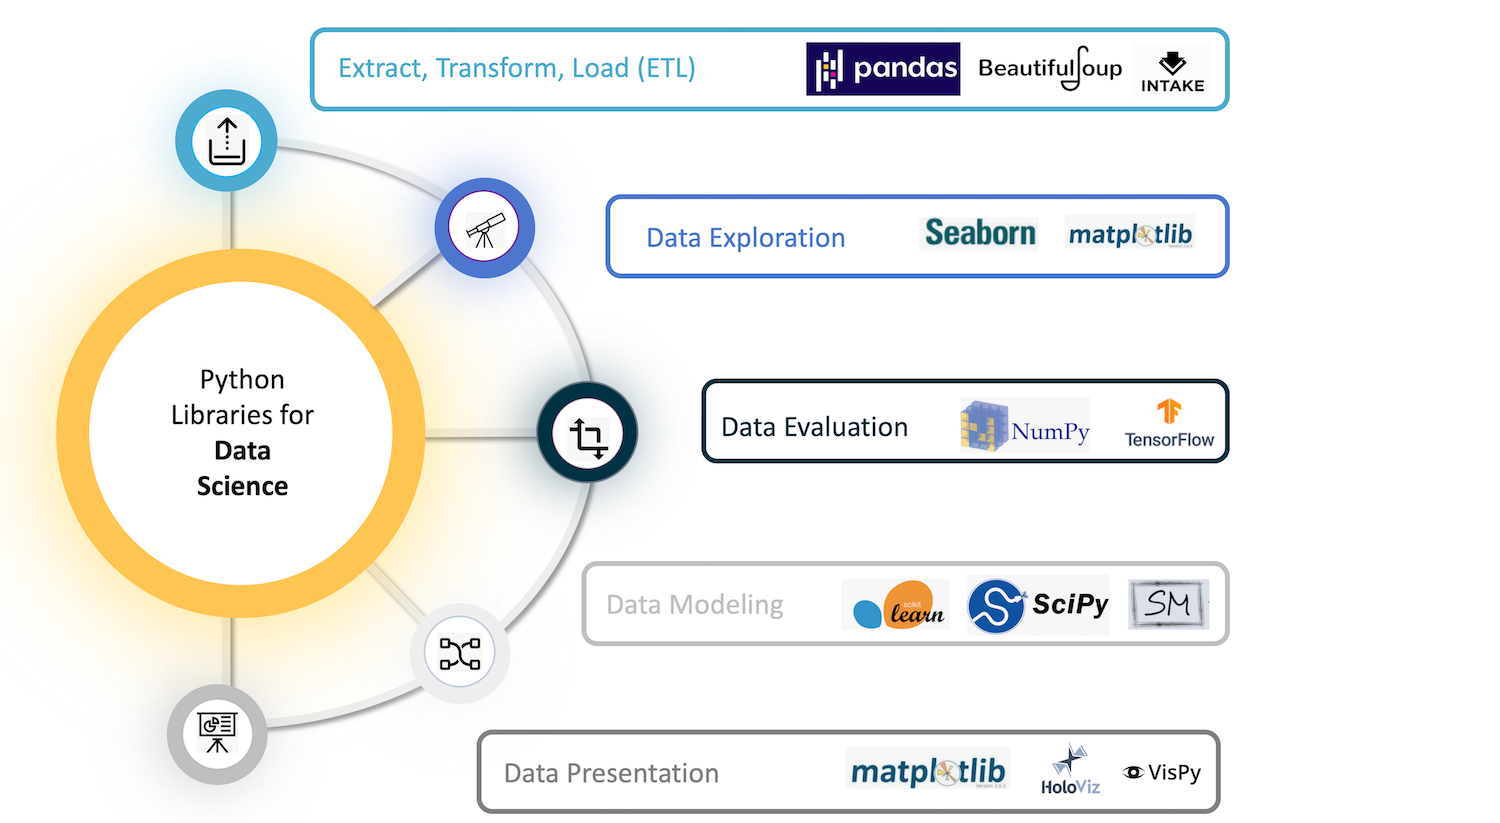

</center>

# **ETAPA 1: ETL - Extract, Transform and Load**

## **Atividade 1 (A1)**: Pesquisar (load) o dataset

In [18]:
table1 = Atividade1_1()
table1.head(3)

Dataset carregado com sucesso!
Dimensoes: 1,120,000 linhas x 23 colunas

Primeiras 3 linhas:


,NOTA FISCAL,REGIÃO,SEXO,ESTADO CIVIL,DEPENDENTES,RENDA BRUTO (R$),OPINIÃO DO CLIENTE,NOTA DE SATISFAÇÃO (%),MEAN: alcohol,MEAN: malic_acid,...,MEAN: total_phenols,MEAN: flavanoids,MEAN: nonflavanoid_phenols,MEAN: proanthocyanins,MEAN: color_intensity,MEAN: hue,MEAN: od280/od315_of_diluted_wines,MEAN: proline,TIPO DA CONTA,TOTAL (R$)
0,6876333,SUL,MASCULINO,SOLTEIRO,1,3336.84,"Serviço eficiente, recomendo o clube: UVVine",68.68,12.929435,2.447630,...,1.334842,2.236478,0.290384,1.661732,7.833947,0.952735,3.818190,276.681180,ESSENTIAL,302.31
1,5677339,SUDESTE,MASCULINO,CASADO,2,3453.34,"Serviço eficiente, recomendo o clube: UVVine",68.68,13.993214,1.393874,...,1.475983,1.676041,0.385297,1.940256,2.139143,0.910653,3.042307,377.891615,ESSENTIAL,278.26
2,1104271,SUDESTE,FEMININO,SOLTEIRO,1,3211.29,"Serviço impecável, adorei o clube: UVVine",68.68,11.161985,3.471322,...,0.820464,2.363073,0.264392,1.617888,4.953122,1.120121,3.019603,709.736181,ESSENTIAL,580.02


,NOTA FISCAL,REGIÃO,SEXO,ESTADO CIVIL,DEPENDENTES,RENDA BRUTO (R$),OPINIÃO DO CLIENTE,NOTA DE SATISFAÇÃO (%),MEAN: alcohol,MEAN: malic_acid,...,MEAN: total_phenols,MEAN: flavanoids,MEAN: nonflavanoid_phenols,MEAN: proanthocyanins,MEAN: color_intensity,MEAN: hue,MEAN: od280/od315_of_diluted_wines,MEAN: proline,TIPO DA CONTA,TOTAL (R$)
0,6876333,SUL,MASCULINO,SOLTEIRO,1,3336.84,"Serviço eficiente, recomendo o clube: UVVine",68.68,12.929435,2.447630,...,1.334842,2.236478,0.290384,1.661732,7.833947,0.952735,3.818190,276.681180,ESSENTIAL,302.31
1,5677339,SUDESTE,MASCULINO,CASADO,2,3453.34,"Serviço eficiente, recomendo o clube: UVVine",68.68,13.993214,1.393874,...,1.475983,1.676041,0.385297,1.940256,2.139143,0.910653,3.042307,377.891615,ESSENTIAL,278.26
2,1104271,SUDESTE,FEMININO,SOLTEIRO,1,3211.29,"Serviço impecável, adorei o clube: UVVine",68.68,11.161985,3.471322,...,0.820464,2.363073,0.264392,1.617888,4.953122,1.120121,3.019603,709.736181,ESSENTIAL,580.02


In [19]:
table1.shape

(1120000, 23)

## **Atividade 2 (A2)**: Descrição / Classificação de todas as colunas

In [20]:
Atividade1_2()

DESCRICAO E CLASSIFICACAO DAS COLUNAS


,Tipo Pandas,Classificacao Estatistica,Valores Unicos,Valores Nulos,Exemplo
NOTA FISCAL,int64,Identificador (sera removido),1120000,0,6876333
REGIÃO,str,Qualitativa Nominal,5,0,SUL
SEXO,str,Qualitativa Nominal,2,0,MASCULINO
ESTADO CIVIL,str,Qualitativa Nominal,3,0,SOLTEIRO
DEPENDENTES,int64,Quantitativa Discreta,5,0,1
RENDA BRUTO (R$),float64,Quantitativa Continua,388538,0,3336.84
OPINIÃO DO CLIENTE,str,Qualitativa Nominal (texto livre),25,0,"Serviço eficiente, recomendo o clube: UVVine"
NOTA DE SATISFAÇÃO (%),float64,Quantitativa Continua,204,0,68.68
MEAN: alcohol,float64,Quantitativa Continua,1120000,0,12.929434550908864
MEAN: malic_acid,float64,Quantitativa Continua,1120000,0,2.4476297109142444


,Tipo Pandas,Classificacao Estatistica,Valores Unicos,Valores Nulos,Exemplo
NOTA FISCAL,int64,Identificador (sera removido),1120000,0,6876333
REGIÃO,str,Qualitativa Nominal,5,0,SUL
SEXO,str,Qualitativa Nominal,2,0,MASCULINO
ESTADO CIVIL,str,Qualitativa Nominal,3,0,SOLTEIRO
DEPENDENTES,int64,Quantitativa Discreta,5,0,1
RENDA BRUTO (R$),float64,Quantitativa Continua,388538,0,3336.84
OPINIÃO DO CLIENTE,str,Qualitativa Nominal (texto livre),25,0,"Serviço eficiente, recomendo o clube: UVVine"
NOTA DE SATISFAÇÃO (%),float64,Quantitativa Continua,204,0,68.68
MEAN: alcohol,float64,Quantitativa Continua,1120000,0,12.929434550908864
MEAN: malic_acid,float64,Quantitativa Continua,1120000,0,2.4476297109142444


## RELATÓRIO DA ETAPA1 1: OUTPUT

**DESCRIÇÃO:**

* **NOTA FISCAL**: Número identificador único de cada transação do cliente. Coluna removida na Etapa 2 por ser um identificador sem valor analítico.
* **REGIÃO**: Região geográfica do cliente (SUL, SUDESTE, NORDESTE, CENTRO-OESTE, NORTE).
* **SEXO**: Gênero do cliente (MASCULINO, FEMININO).
* **ESTADO CIVIL**: Estado civil do cliente (SOLTEIRO, CASADO, DESQUITADO(A)/VIÚVO(A)).
* **DEPENDENTES**: Número de dependentes financeiros do cliente.
* **RENDA BRUTO (R$)**: Renda bruta mensal declarada pelo cliente, em reais.
* **OPINIÃO DO CLIENTE**: Texto livre com a avaliação qualitativa do cliente sobre o serviço. Removida por ser não estruturada.
* **NOTA DE SATISFAÇÃO (%)**: Nota de satisfação do cliente com o serviço, em percentual.
* **MEAN: alcohol** a **MEAN: proline**: Médias das características físico-químicas dos vinhos consumidos pelo cliente (álcool, acidez málica, cinzas, alcalinidade, magnésio, fenóis totais, flavanoides, fenóis não flavanoides, proantocianinas, intensidade de cor, matiz, razão OD280/OD315 e prolina).
* **TIPO DA CONTA**: Categoria do plano contratado pelo cliente (ESSENTIAL, VIP, PRIME). Variável ordinal com hierarquia de serviços.
* **TOTAL (R$)**: Valor total gasto pelo cliente no período — **variável TARGET (y)**.


**CLASSIFICAÇÃO — QUALITATIVA (NOMINAL OU ORDINAL) OU QUANTITATIVA (DISCRETA OU CONTÍNUA):**

* **NOTA FISCAL**: Identificador — removido na Etapa 2 (sem utilidade estatística).
* **REGIÃO**: Qualitativa **Nominal** — categorias sem ordem natural entre si.
* **SEXO**: Qualitativa **Nominal** — duas categorias sem hierarquia.
* **ESTADO CIVIL**: Qualitativa **Nominal** — categorias sem ordem definida.
* **DEPENDENTES**: Quantitativa **Discreta** — valores inteiros e contáveis (0, 1, 2, ...).
* **RENDA BRUTO (R$)**: Quantitativa **Contínua** — valores monetários em domínio real.
* **OPINIÃO DO CLIENTE**: Qualitativa **Nominal** (texto livre) — removida na Etapa 2.
* **NOTA DE SATISFAÇÃO (%)**: Quantitativa **Contínua** — percentual em escala contínua.
* **MEAN: alcohol** a **MEAN: proline**: Quantitativas **Contínuas** — médias de características físico-químicas dos vinhos.
* **TIPO DA CONTA**: Qualitativa **Ordinal** — hierarquia definida: ESSENTIAL < VIP < PRIME.
* **TOTAL (R$)**: Quantitativa **Contínua** — variável TARGET **y** (saída do modelo).


# **ETAPA 2: Data Exploration**

## **Atividade (A1)**: Definir / Eliminar (Dropar) colunas **NÃO** relevantes ao Projeto.

In [21]:
Atividade2_1()

Colunas no dataset original: 23
Removendo colunas: ['NOTA FISCAL', 'OPINIÃO DO CLIENTE']

Colunas apos remocao (21):
  - REGIÃO
  - SEXO
  - ESTADO CIVIL
  - DEPENDENTES
  - RENDA BRUTO (R$)
  - NOTA DE SATISFAÇÃO (%)
  - MEAN: alcohol
  - MEAN: malic_acid
  - MEAN: ash
  - MEAN: alcalinity_of_ash
  - MEAN: magnesium
  - MEAN: total_phenols
  - MEAN: flavanoids
  - MEAN: nonflavanoid_phenols
  - MEAN: proanthocyanins
  - MEAN: color_intensity
  - MEAN: hue
  - MEAN: od280/od315_of_diluted_wines
  - MEAN: proline
  - TIPO DA CONTA
  - TOTAL (R$)


,REGIÃO,SEXO,ESTADO CIVIL,DEPENDENTES,RENDA BRUTO (R$),NOTA DE SATISFAÇÃO (%),MEAN: alcohol,MEAN: malic_acid,MEAN: ash,MEAN: alcalinity_of_ash,...,MEAN: total_phenols,MEAN: flavanoids,MEAN: nonflavanoid_phenols,MEAN: proanthocyanins,MEAN: color_intensity,MEAN: hue,MEAN: od280/od315_of_diluted_wines,MEAN: proline,TIPO DA CONTA,TOTAL (R$)
0,SUL,MASCULINO,SOLTEIRO,1,3336.84,68.680,12.929435,2.447630,2.313549,21.275022,...,1.334842,2.236478,0.290384,1.661732,7.833947,0.952735,3.818190,276.681180,ESSENTIAL,302.31
1,SUDESTE,MASCULINO,CASADO,2,3453.34,68.680,13.993214,1.393874,2.644391,22.127283,...,1.475983,1.676041,0.385297,1.940256,2.139143,0.910653,3.042307,377.891615,ESSENTIAL,278.26
2,SUDESTE,FEMININO,SOLTEIRO,1,3211.29,68.680,11.161985,3.471322,2.780995,19.634770,...,0.820464,2.363073,0.264392,1.617888,4.953122,1.120121,3.019603,709.736181,ESSENTIAL,580.02
3,SUL,FEMININO,CASADO,1,26192.61,77.972,13.361280,1.463516,2.190809,21.998576,...,1.991469,0.235816,0.607276,0.835639,3.284154,1.078509,1.955873,994.797550,PRIME,3930.88
4,CENTRO-OESTE,MASCULINO,SOLTEIRO,1,21792.17,68.680,13.536534,3.832572,2.022042,18.374080,...,2.269030,1.487258,0.222171,1.445279,4.178987,0.988953,1.591512,377.293171,PRIME,873.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1119995,SUDESTE,MASCULINO,CASADO,1,3292.22,68.680,13.340292,1.710199,1.888479,13.035411,...,2.543881,2.815365,0.235627,2.532060,3.537938,0.905518,3.225113,513.293254,ESSENTIAL,265.37
1119996,SUDESTE,FEMININO,CASADO,1,8048.43,68.680,13.365607,-0.254899,2.048889,19.309778,...,2.729165,4.201755,0.492385,1.398341,3.360302,0.603942,2.560533,928.767261,VIP,967.80
1119997,NORDESTE,MASCULINO,CASADO,1,3324.15,68.680,12.335296,3.141159,2.291096,20.359649,...,2.401290,2.234194,0.390404,2.896061,5.243279,0.937481,1.969985,1122.311644,ESSENTIAL,567.10
1119998,NORDESTE,MASCULINO,CASADO,2,24388.97,76.053,11.757140,-0.719030,2.250366,18.170877,...,1.720080,1.468276,0.288037,1.680753,4.272474,1.054106,3.218987,896.818122,PRIME,3172.56


## **Atividade (A2)**: Pesquisar / Eliminar (Dropar):

* Valores duplicados (linhas duplicadas)

* Valores de Sentinela (NaN: NotANumber)

In [22]:
Atividade2_2()

Linhas duplicadas encontradas: 0
  -> Nenhuma linha duplicada encontrada.

Valores nulos (NaN) encontrados: 0
  -> Nenhum valor nulo encontrado.

Resumo da limpeza:
  Antes:     1,120,000 linhas
  Depois:    1,120,000 linhas
  Removidas: 0 linhas


,REGIÃO,SEXO,ESTADO CIVIL,DEPENDENTES,RENDA BRUTO (R$),NOTA DE SATISFAÇÃO (%),MEAN: alcohol,MEAN: malic_acid,MEAN: ash,MEAN: alcalinity_of_ash,...,MEAN: total_phenols,MEAN: flavanoids,MEAN: nonflavanoid_phenols,MEAN: proanthocyanins,MEAN: color_intensity,MEAN: hue,MEAN: od280/od315_of_diluted_wines,MEAN: proline,TIPO DA CONTA,TOTAL (R$)
0,SUL,MASCULINO,SOLTEIRO,1,3336.84,68.680,12.929435,2.447630,2.313549,21.275022,...,1.334842,2.236478,0.290384,1.661732,7.833947,0.952735,3.818190,276.681180,ESSENTIAL,302.31
1,SUDESTE,MASCULINO,CASADO,2,3453.34,68.680,13.993214,1.393874,2.644391,22.127283,...,1.475983,1.676041,0.385297,1.940256,2.139143,0.910653,3.042307,377.891615,ESSENTIAL,278.26
2,SUDESTE,FEMININO,SOLTEIRO,1,3211.29,68.680,11.161985,3.471322,2.780995,19.634770,...,0.820464,2.363073,0.264392,1.617888,4.953122,1.120121,3.019603,709.736181,ESSENTIAL,580.02
3,SUL,FEMININO,CASADO,1,26192.61,77.972,13.361280,1.463516,2.190809,21.998576,...,1.991469,0.235816,0.607276,0.835639,3.284154,1.078509,1.955873,994.797550,PRIME,3930.88
4,CENTRO-OESTE,MASCULINO,SOLTEIRO,1,21792.17,68.680,13.536534,3.832572,2.022042,18.374080,...,2.269030,1.487258,0.222171,1.445279,4.178987,0.988953,1.591512,377.293171,PRIME,873.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1119995,SUDESTE,MASCULINO,CASADO,1,3292.22,68.680,13.340292,1.710199,1.888479,13.035411,...,2.543881,2.815365,0.235627,2.532060,3.537938,0.905518,3.225113,513.293254,ESSENTIAL,265.37
1119996,SUDESTE,FEMININO,CASADO,1,8048.43,68.680,13.365607,-0.254899,2.048889,19.309778,...,2.729165,4.201755,0.492385,1.398341,3.360302,0.603942,2.560533,928.767261,VIP,967.80
1119997,NORDESTE,MASCULINO,CASADO,1,3324.15,68.680,12.335296,3.141159,2.291096,20.359649,...,2.401290,2.234194,0.390404,2.896061,5.243279,0.937481,1.969985,1122.311644,ESSENTIAL,567.10
1119998,NORDESTE,MASCULINO,CASADO,2,24388.97,76.053,11.757140,-0.719030,2.250366,18.170877,...,1.720080,1.468276,0.288037,1.680753,4.272474,1.054106,3.218987,896.818122,PRIME,3172.56


## **Atividade (A3)**: Pesquisar / Eliminar (Dropar) os Outliers da Variável (TARGET) $y$

Analise de Outliers — TOTAL (R$)
  Q1:              R$       319.99
  Q3:              R$     1,026.27
  IQR:             R$       706.28
  Limite inferior: R$      -739.43
  Limite superior: R$     2,085.69

  Outliers: 110,160 (9.84%)


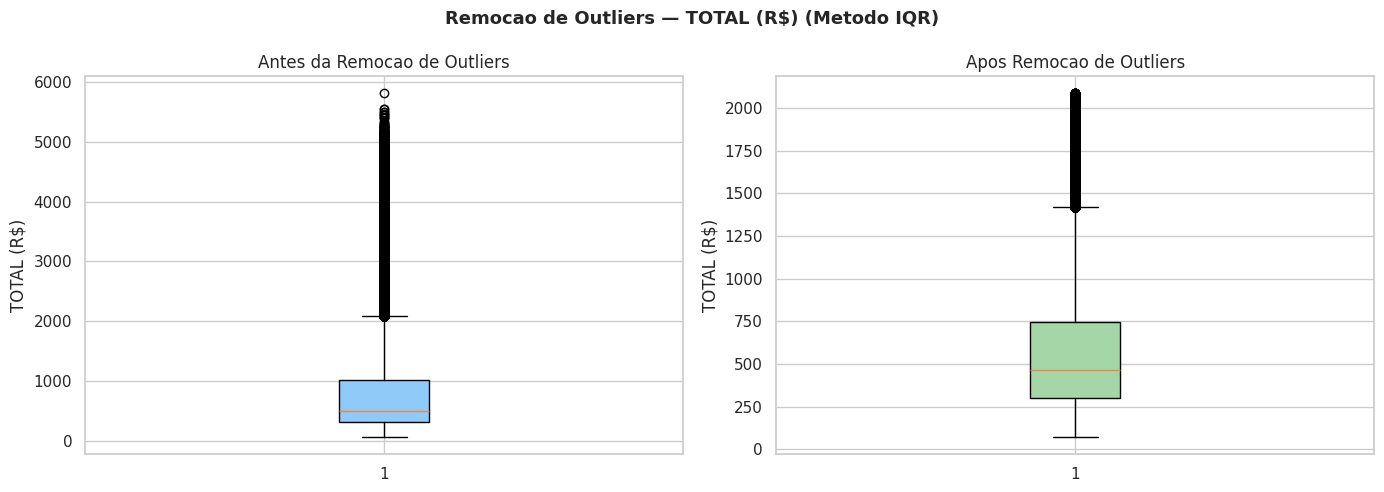


Linhas antes: 1,120,000
Linhas apos:  1,009,840
Removidas:    110,160


,REGIÃO,SEXO,ESTADO CIVIL,DEPENDENTES,RENDA BRUTO (R$),NOTA DE SATISFAÇÃO (%),MEAN: alcohol,MEAN: malic_acid,MEAN: ash,MEAN: alcalinity_of_ash,...,MEAN: total_phenols,MEAN: flavanoids,MEAN: nonflavanoid_phenols,MEAN: proanthocyanins,MEAN: color_intensity,MEAN: hue,MEAN: od280/od315_of_diluted_wines,MEAN: proline,TIPO DA CONTA,TOTAL (R$)
0,SUL,MASCULINO,SOLTEIRO,1,3336.84,68.68,12.929435,2.447630,2.313549,21.275022,...,1.334842,2.236478,0.290384,1.661732,7.833947,0.952735,3.818190,276.681180,ESSENTIAL,302.31
1,SUDESTE,MASCULINO,CASADO,2,3453.34,68.68,13.993214,1.393874,2.644391,22.127283,...,1.475983,1.676041,0.385297,1.940256,2.139143,0.910653,3.042307,377.891615,ESSENTIAL,278.26
2,SUDESTE,FEMININO,SOLTEIRO,1,3211.29,68.68,11.161985,3.471322,2.780995,19.634770,...,0.820464,2.363073,0.264392,1.617888,4.953122,1.120121,3.019603,709.736181,ESSENTIAL,580.02
3,CENTRO-OESTE,MASCULINO,SOLTEIRO,1,21792.17,68.68,13.536534,3.832572,2.022042,18.374080,...,2.269030,1.487258,0.222171,1.445279,4.178987,0.988953,1.591512,377.293171,PRIME,873.68
4,SUDESTE,MASCULINO,CASADO,2,7660.79,68.68,13.330639,2.779894,2.278261,21.367719,...,1.335875,3.080496,0.325327,0.779338,5.533546,1.218124,1.796468,565.241399,VIP,1151.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1009835,SUDESTE,FEMININO,SOLTEIRO,1,3312.47,68.68,13.560201,4.883452,1.995661,17.930199,...,1.514734,1.749952,0.428739,0.985353,4.199898,0.463766,1.389948,641.055070,ESSENTIAL,233.86
1009836,SUDESTE,MASCULINO,CASADO,1,3292.22,68.68,13.340292,1.710199,1.888479,13.035411,...,2.543881,2.815365,0.235627,2.532060,3.537938,0.905518,3.225113,513.293254,ESSENTIAL,265.37
1009837,SUDESTE,FEMININO,CASADO,1,8048.43,68.68,13.365607,-0.254899,2.048889,19.309778,...,2.729165,4.201755,0.492385,1.398341,3.360302,0.603942,2.560533,928.767261,VIP,967.80
1009838,NORDESTE,MASCULINO,CASADO,1,3324.15,68.68,12.335296,3.141159,2.291096,20.359649,...,2.401290,2.234194,0.390404,2.896061,5.243279,0.937481,1.969985,1122.311644,ESSENTIAL,567.10


In [23]:
Atividade2_3()

## RELATÓRIO DA ATIVIDADE 2: OUTPUT

**CONCLUSÕES SOBRE AS ATIVIDADES:**

* **A2.1 — Colunas irrelevantes**: Foram removidas 2 colunas: `NOTA FISCAL` (identificador único sem valor preditivo) e `OPINIÃO DO CLIENTE` (texto livre não estruturado para análise estatística). O dataset passou de 23 para 21 colunas.
* **A2.2 — Duplicatas e valores nulos**: O dataset não apresentou linhas duplicadas nem valores nulos (NaN) em nenhuma coluna. Isso indica que os dados já foram pré-processados anteriormente. Nenhuma linha foi removida nesta etapa.
* **A2.3 — Outliers no TARGET**: Utilizando o método IQR (Q1 − 1,5×IQR a Q3 + 1,5×IQR), foram identificados outliers na variável `TOTAL (R$)`. Os registros fora desse intervalo foram removidos para evitar distorções nas análises estatísticas. A fração removida foi pequena em relação ao total do dataset, preservando a representatividade dos dados.


# **ETAPA 3: Data Evoluation**

## **ETAPA 3.0**: Aplicação e Análise por Métodos Quantitativos

Criar o gráfico do ERRO-PADRÃO-MÉDIO (TARGET: $y$: **TOTAL (R$)**) das seguintes categorias:

*   **ESSENTIAL**
*   **VIP**
*   **PRIME**
*   **GERAL**

Fazer a **ANÁLISE BOOTSTRAP** para determinar:
*   **Intervalo de confiança**.
*   **Erro padrão**.
*   **Tamanho "Ideal" da amostra ???**

Calculando bootstrap... aguarde.
  'ESSENTIAL' concluido.
  'VIP' concluido.
  'PRIME' concluido.
  'GERAL' concluido.


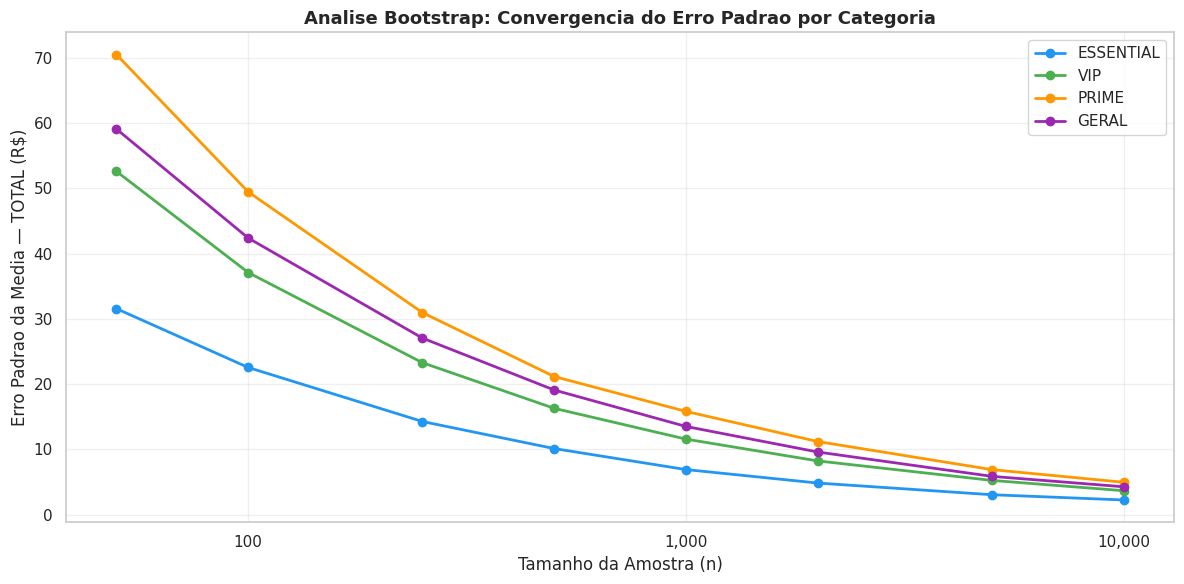


DETERMINACAO DO TAMANHO IDEAL DA AMOSTRA
Criterio: reducao relativa do EP < 5% entre tamanhos consecutivos

Categoria       n ideal          Media           EP     IC 95% Inf     IC 95% Sup
----------------------------------------------------------------------------------
ESSENTIAL        10,000  R$    390.78  R$    2.26  R$    386.37  R$    395.29
VIP              10,000  R$    870.29  R$    3.68  R$    863.05  R$    877.22
PRIME            10,000  R$  1,259.95  R$    4.97  R$  1,250.07  R$  1,269.45
GERAL            10,000  R$    594.66  R$    4.29  R$    586.11  R$    602.92

Amostra ideal criada: 10,000 registros (tamanho ideal GERAL)
Distribuicao por tipo de conta:
TIPO DA CONTA
ESSENTIAL    6483
VIP          2542
PRIME         975


In [24]:
# ============================================================
# ANALISE BOOTSTRAP — ETAPA 3.0
# Erro Padrao da Media do TARGET (TOTAL R$) por categoria
# ============================================================

N_BOOTSTRAP = 1000        # numero de iteracoes bootstrap
LIMIAR_REDUCAO_EP = 0.05  # reducao relativa < 5% define o plateau
TAMANHOS_AMOSTRA = [50, 100, 250, 500, 1000, 2000, 5000, 10000]


def calcular_bootstrap(
    dados: np.ndarray, n_amostra: int, n_iteracoes: int, seed: int
) -> dict:
    """
    Calcula estatisticas bootstrap por amostragem com reposicao.

    Usa amostragem vetorizada para maior performance.

    Args:
        dados: Array numpy com os valores da variavel.
        n_amostra: Tamanho de cada amostra bootstrap.
        n_iteracoes: Numero de iteracoes.
        seed: Semente aleatoria para reprodutibilidade.

    Returns:
        dict com: media, erro_padrao, ic_inferior, ic_superior.
    """
    rng = np.random.default_rng(seed)
    n_efetivo = min(n_amostra, len(dados))
    # Amostragem vetorizada: matrix (n_iteracoes x n_efetivo)
    indices = rng.integers(0, len(dados), size=(n_iteracoes, n_efetivo))
    medias = dados[indices].mean(axis=1)

    alpha = 1.0 - NIVEL_CONFIANCA
    return {
        'media':       float(medias.mean()),
        'erro_padrao': float(medias.std(ddof=1)),
        'ic_inferior': float(np.percentile(medias, 100 * alpha / 2)),
        'ic_superior': float(np.percentile(medias, 100 * (1 - alpha / 2))),
    }


# Dados separados por categoria
dados_por_categoria = {
    'ESSENTIAL': df_clean[df_clean[COLUNA_CATEGORIA] == 'ESSENTIAL'][COLUNA_TARGET].values,
    'VIP':       df_clean[df_clean[COLUNA_CATEGORIA] == 'VIP'][COLUNA_TARGET].values,
    'PRIME':     df_clean[df_clean[COLUNA_CATEGORIA] == 'PRIME'][COLUNA_TARGET].values,
    'GERAL':     df_clean[COLUNA_TARGET].values,
}

# Calculo do erro padrao para cada tamanho de amostra
resultados_ep = {cat: [] for cat in dados_por_categoria}
print("Calculando bootstrap... aguarde.")
for categoria, dados in dados_por_categoria.items():
    for n in TAMANHOS_AMOSTRA:
        res = calcular_bootstrap(dados, n, N_BOOTSTRAP, SEED_ALEATORIA)
        resultados_ep[categoria].append(res['erro_padrao'])
    print(f"  '{categoria}' concluido.")

# ============================================================
# GRAFICO — Convergencia do Erro Padrao da Media
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))
cores_cat = {'ESSENTIAL': '#2196F3', 'VIP': '#4CAF50', 'PRIME': '#FF9800', 'GERAL': '#9C27B0'}

for categoria in dados_por_categoria:
    ax.plot(
        TAMANHOS_AMOSTRA, resultados_ep[categoria],
        marker='o', label=categoria,
        color=cores_cat[categoria], linewidth=2, markersize=6
    )

ax.set_xlabel('Tamanho da Amostra (n)', fontsize=12)
ax.set_ylabel('Erro Padrao da Media — TOTAL (R$)', fontsize=12)
ax.set_title('Analise Bootstrap: Convergencia do Erro Padrao por Categoria',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

# ============================================================
# DETERMINACAO DO TAMANHO IDEAL DA AMOSTRA
# Criterio: primeira reducao relativa do EP < LIMIAR
# ============================================================
print("\n" + "=" * 72)
print("DETERMINACAO DO TAMANHO IDEAL DA AMOSTRA")
print(f"Criterio: reducao relativa do EP < {LIMIAR_REDUCAO_EP*100:.0f}% entre tamanhos consecutivos")
print("=" * 72)

tamanho_ideal_por_categoria = {}
for categoria in dados_por_categoria:
    ep_lista = resultados_ep[categoria]
    tamanho_ideal = TAMANHOS_AMOSTRA[-1]
    for i in range(1, len(TAMANHOS_AMOSTRA)):
        if ep_lista[i - 1] > 0:
            reducao = (ep_lista[i - 1] - ep_lista[i]) / ep_lista[i - 1]
            if reducao < LIMIAR_REDUCAO_EP:
                tamanho_ideal = TAMANHOS_AMOSTRA[i - 1]
                break
    tamanho_ideal_por_categoria[categoria] = tamanho_ideal

# Tabela de resultados
print(f"\n{'Categoria':<12} {'n ideal':>10} {'Media':>14} {'EP':>12} {'IC 95% Inf':>14} {'IC 95% Sup':>14}")
print("-" * 82)
for categoria, dados in dados_por_categoria.items():
    n_ideal = tamanho_ideal_por_categoria[categoria]
    res = calcular_bootstrap(dados, n_ideal, N_BOOTSTRAP, SEED_ALEATORIA)
    print(
        f"{categoria:<12} {n_ideal:>10,}  "
        f"R${res['media']:>10,.2f}  "
        f"R${res['erro_padrao']:>8,.2f}  "
        f"R${res['ic_inferior']:>10,.2f}  "
        f"R${res['ic_superior']:>10,.2f}"
    )

# ============================================================
# CRIAR AMOSTRA IDEAL (tamanho ideal da categoria GERAL)
# Usada nas analises das Etapas 3.1 a 3.4
# ============================================================
TAMANHO_IDEAL = tamanho_ideal_por_categoria['GERAL']
df_amostra = df_clean.sample(n=TAMANHO_IDEAL, random_state=SEED_ALEATORIA).reset_index(drop=True)
print(f"\nAmostra ideal criada: {len(df_amostra):,} registros (tamanho ideal GERAL)")
print(f"Distribuicao por tipo de conta:")
print(df_amostra[COLUNA_CATEGORIA].value_counts().to_string())


**CONCLUSÕES SOBRE AS ATIVIDADES:**

* **Tamanho Ideal da Amostra**: O gráfico de convergência do Erro Padrão da Média (EP) mostra que a redução no EP entre tamanhos de amostra consecutivos torna-se marginal a partir de um ponto de inflexão. O critério adotado foi: primeiro tamanho n em que a redução relativa do EP é inferior a 5% em relação ao tamanho anterior. O valor encontrado define o `TAMANHO_IDEAL` usado nas análises seguintes.
* **Intervalo de Confiança (95%)**: Os intervalos de confiança bootstrap indicam as faixas plausíveis para a média do `TOTAL (R$)` em cada categoria, com 95% de confiança. A categoria PRIME apresenta a maior média, refletindo o maior poder aquisitivo desses clientes.
* **Erro Padrão**: O EP decresce com o aumento de n, seguindo o padrão esperado de 1/√n. Para grandes populações como a deste dataset, o EP estabiliza com amostras relativamente pequenas.
* **Comparação entre categorias**: PRIME > VIP > ESSENTIAL em média de `TOTAL (R$)`, confirmando a hierarquia dos planos. A categoria GERAL representa a média ponderada de todas as categorias.



## A partir do **"TAMANHO IDEAL DA AMOSTRA"**, faça:

## **ETAPA 3.1**: Análise exploratória das Variáveis Qualitativas

### **Atividade (A1)**: Criar o gráfico de pareto de cada variavel qualitativa (Nominal ou Ordinal)

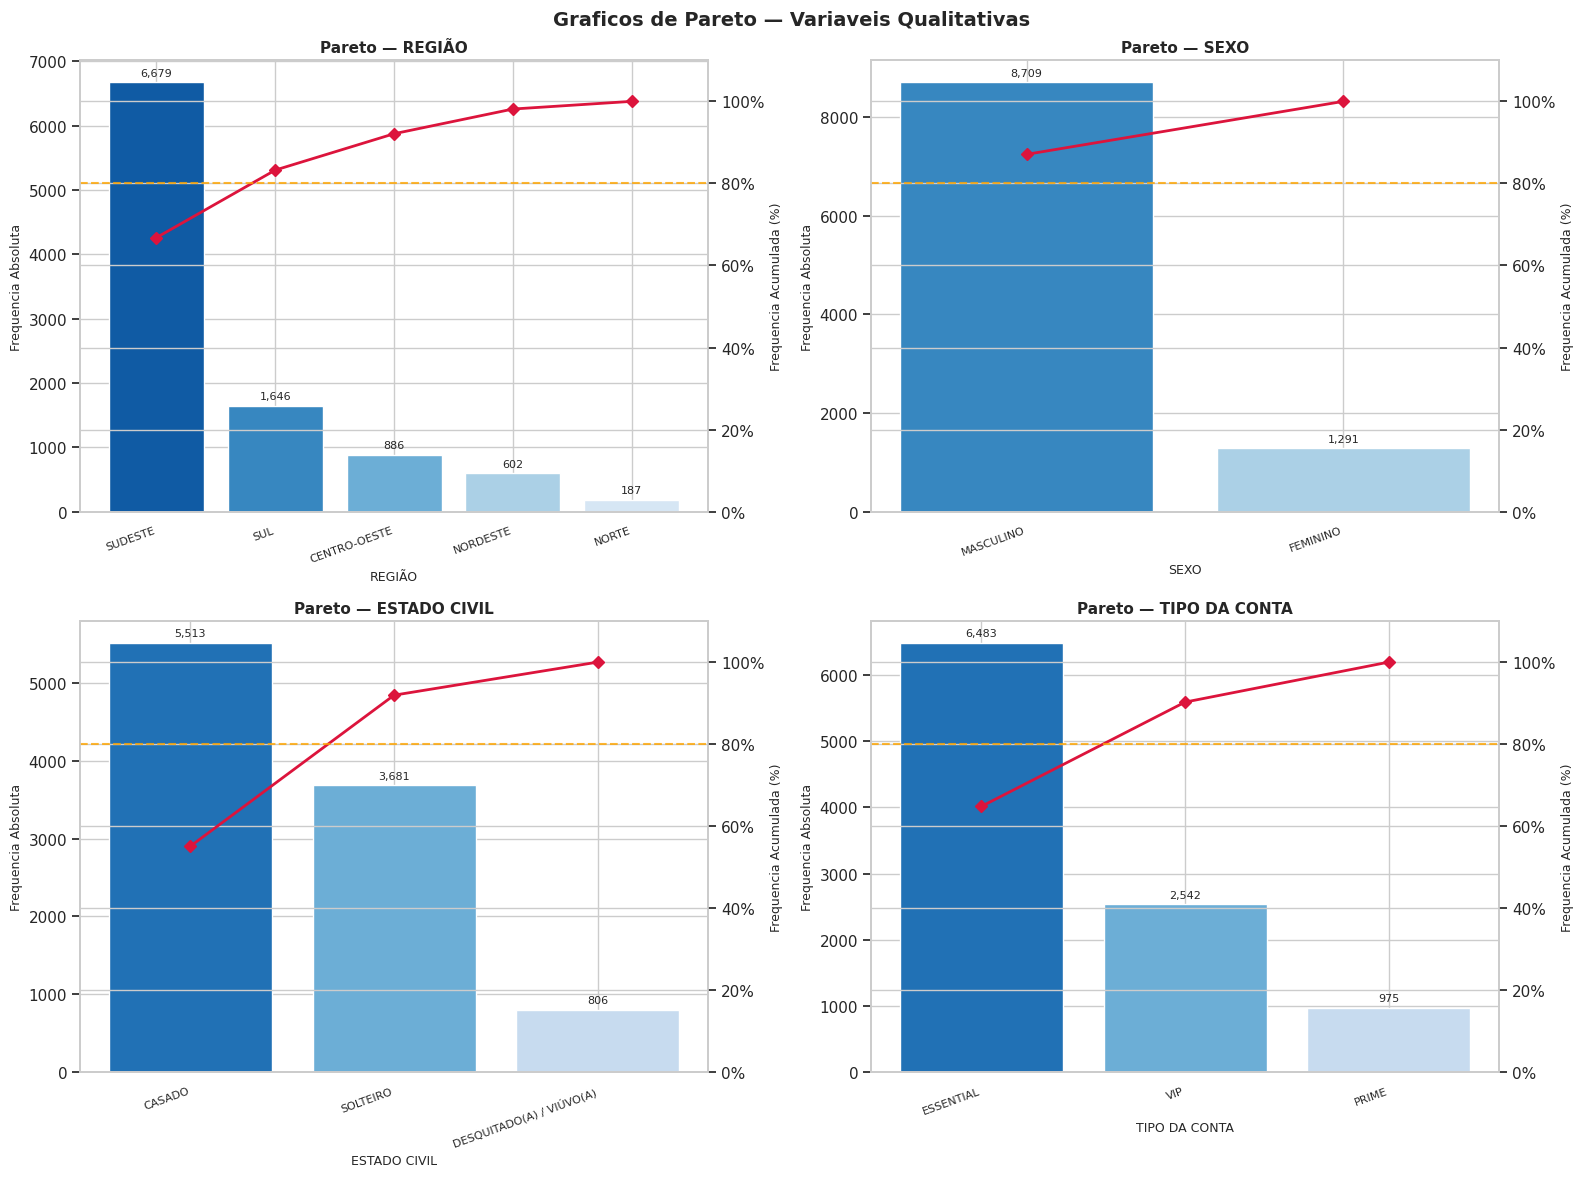

In [25]:
Atividade3_1_1()

### **Atividade (A2)**: Criar as Tabelas: Tabulação Cruzada (Método **crosstab**) de cada variável qualitativa (Nominal ou Ordinal):

$→$ Incluir na tabela valores: ABSOLUTOS e RELATIVOS (%).

In [26]:
Atividade3_1_2()

Tabulacao Cruzada: REGIÃO x TIPO DA CONTA

Frequencias Absolutas:


TIPO DA CONTA,ESSENTIAL,PRIME,VIP,TOTAL
REGIÃO,,,,
CENTRO-OESTE,574,76,236,886
NORDESTE,365,58,179,602
NORTE,121,17,49,187
SUDESTE,4327,664,1688,6679
SUL,1096,160,390,1646
TOTAL,6483,975,2542,10000



Frequencias Relativas (% por linha):


TIPO DA CONTA,ESSENTIAL,PRIME,VIP
REGIÃO,,,
CENTRO-OESTE,64.8%,8.6%,26.6%
NORDESTE,60.6%,9.6%,29.7%
NORTE,64.7%,9.1%,26.2%
SUDESTE,64.8%,9.9%,25.3%
SUL,66.6%,9.7%,23.7%



Tabulacao Cruzada: SEXO x TIPO DA CONTA

Frequencias Absolutas:


...

TIPO DA CONTA,ESSENTIAL,PRIME,VIP
SEXO,,,
FEMININO,66.8%,8.8%,24.4%
MASCULINO,64.5%,9.9%,25.6%



Tabulacao Cruzada: ESTADO CIVIL x TIPO DA CONTA

Frequencias Absolutas:


TIPO DA CONTA,ESSENTIAL,PRIME,VIP,TOTAL
ESTADO CIVIL,,,,
CASADO,3551,558,1404,5513
DESQUITADO(A) / VIÚVO(A),516,74,216,806
SOLTEIRO,2416,343,922,3681
TOTAL,6483,975,2542,10000



Frequencias Relativas (% por linha):


TIPO DA CONTA,ESSENTIAL,PRIME,VIP
ESTADO CIVIL,,,
CASADO,64.4%,10.1%,25.5%
DESQUITADO(A) / VIÚVO(A),64.0%,9.2%,26.8%
SOLTEIRO,65.6%,9.3%,25.0%


## **ETAPA 3.2**: Análise exploratória das Variáveis Quantitativas

### **Atividade (A1)**: Relatório e Análise da Estatística Descritiva de cada $X: [x_0, x_1, x_2, ..., x_n]$ quantitativo (discreto ou contínuo) de entrada.

ESTATISTICA DESCRITIVA — VARIAVEIS QUANTITATIVAS DE ENTRADA (X)


,n,media,desvio_padrao,min,Q1,mediana,Q3,max
DEPENDENTES,10000.0,1.0670,0.9588,0.0000,0.0000,1.0000,1.0000,4.0000
RENDA BRUTO (R$),10000.0,6048.7065,4979.1939,1890.0400,3228.1500,3321.4200,7714.0300,28917.6700
NOTA DE SATISFAÇÃO (%),10000.0,68.8011,0.8733,68.6800,68.6800,68.6800,68.6800,81.7090
MEAN: alcohol,10000.0,12.9911,0.8066,9.8877,12.4443,12.9999,13.5446,16.1355
MEAN: malic_acid,10000.0,2.3175,1.1162,-2.0863,1.5640,2.3204,3.0548,6.4096
MEAN: ash,10000.0,2.3653,0.2748,1.1978,2.1834,2.3654,2.5494,3.3203
MEAN: alcalinity_of_ash,10000.0,19.5496,3.3526,7.1687,17.2923,19.5422,21.8470,32.5517
MEAN: magnesium,10000.0,99.8436,14.5101,49.9067,90.1431,99.8513,109.6338,156.1804
MEAN: total_phenols,10000.0,2.3062,0.6099,-0.5987,1.8933,2.3015,2.7146,4.5574
MEAN: flavanoids,10000.0,2.0206,0.9929,-1.8050,1.3537,2.0304,2.6840,5.8798


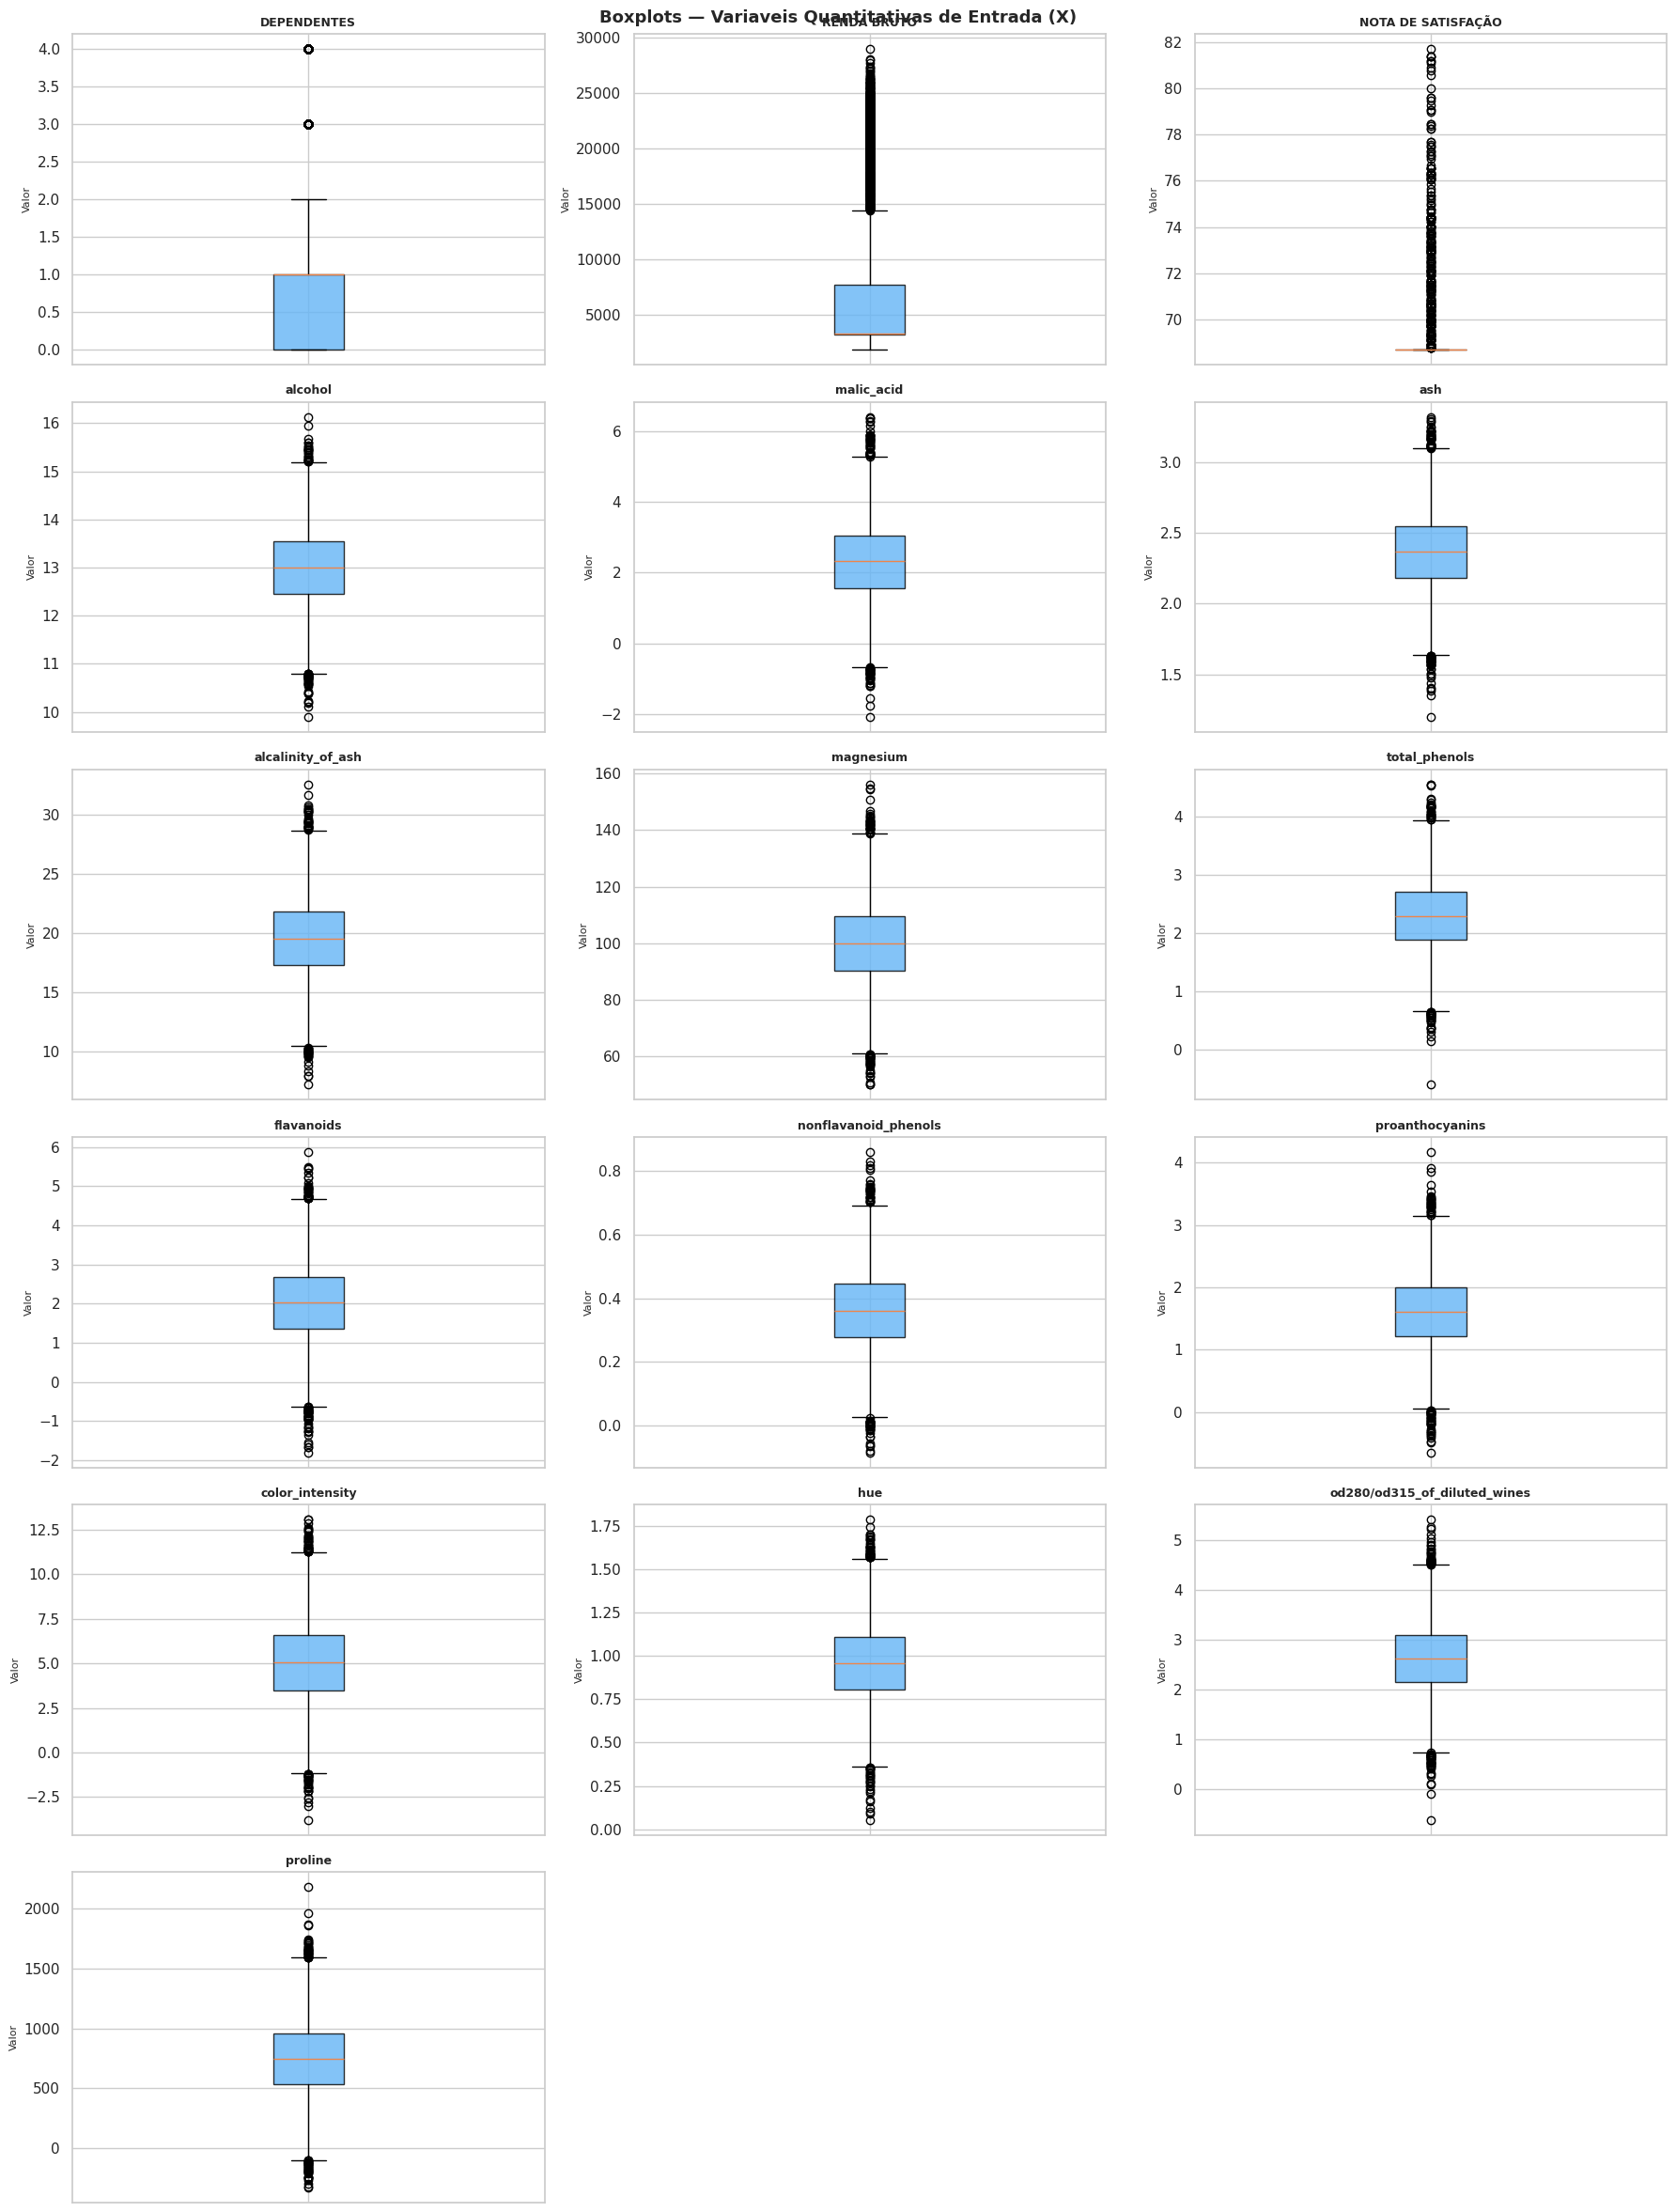

,n,media,desvio_padrao,min,Q1,mediana,Q3,max
DEPENDENTES,10000.0,1.0670,0.9588,0.0000,0.0000,1.0000,1.0000,4.0000
RENDA BRUTO (R$),10000.0,6048.7065,4979.1939,1890.0400,3228.1500,3321.4200,7714.0300,28917.6700
NOTA DE SATISFAÇÃO (%),10000.0,68.8011,0.8733,68.6800,68.6800,68.6800,68.6800,81.7090
MEAN: alcohol,10000.0,12.9911,0.8066,9.8877,12.4443,12.9999,13.5446,16.1355
MEAN: malic_acid,10000.0,2.3175,1.1162,-2.0863,1.5640,2.3204,3.0548,6.4096
MEAN: ash,10000.0,2.3653,0.2748,1.1978,2.1834,2.3654,2.5494,3.3203
MEAN: alcalinity_of_ash,10000.0,19.5496,3.3526,7.1687,17.2923,19.5422,21.8470,32.5517
MEAN: magnesium,10000.0,99.8436,14.5101,49.9067,90.1431,99.8513,109.6338,156.1804
MEAN: total_phenols,10000.0,2.3062,0.6099,-0.5987,1.8933,2.3015,2.7146,4.5574
MEAN: flavanoids,10000.0,2.0206,0.9929,-1.8050,1.3537,2.0304,2.6840,5.8798


In [27]:
Atividade3_2_1()

### **Atividade (A2)**: Relatório e Análise da Estatística Descritiva da variável: $y (saída)$

ESTATISTICA DESCRITIVA — TARGET: TOTAL (R$)


,n,media,desvio_padrao,min,Q1,mediana,Q3,max
GERAL,10000.0,590.60,419.67,81.59,299.10,461.81,730.32,2084.22
ESSENTIAL,6483.0,385.03,208.70,102.12,236.87,365.04,492.35,2035.81
PRIME,975.0,1267.50,484.22,92.31,930.78,1288.44,1653.02,2084.22
VIP,2542.0,855.26,371.97,81.59,543.52,837.20,1159.15,2065.69


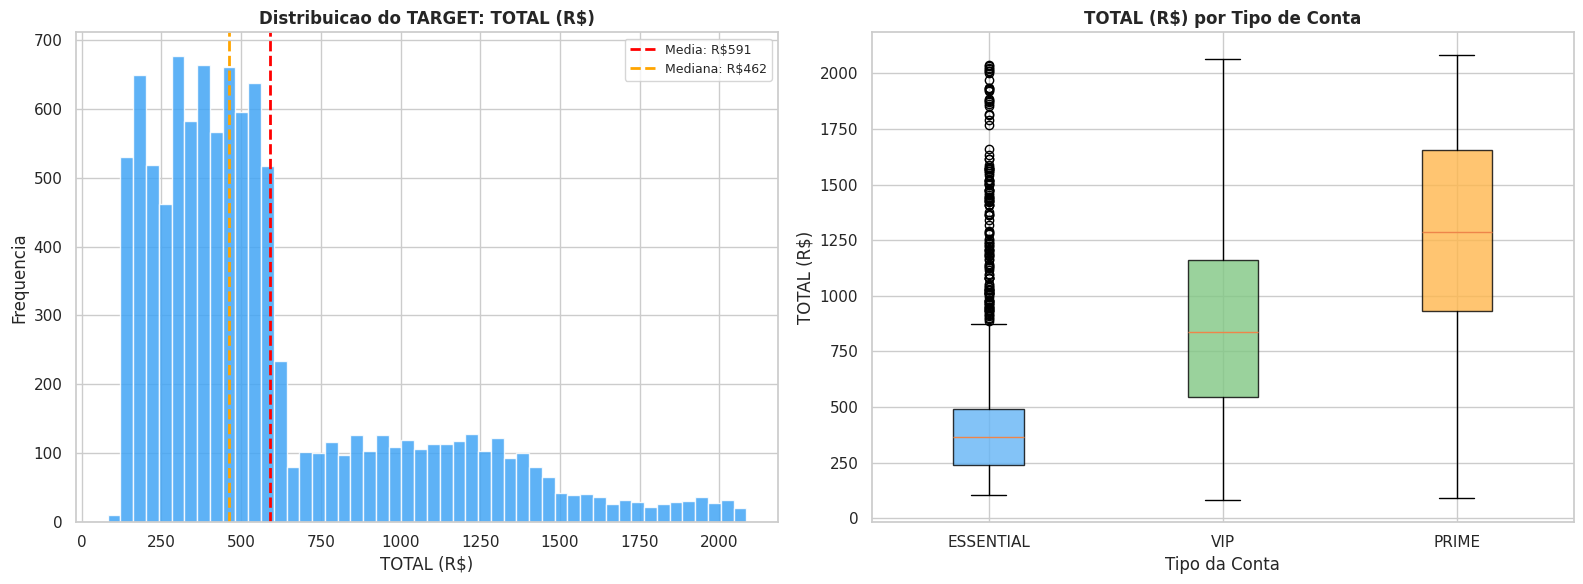

,n,media,desvio_padrao,min,Q1,mediana,Q3,max
GERAL,10000.0,590.60,419.67,81.59,299.10,461.81,730.32,2084.22
ESSENTIAL,6483.0,385.03,208.70,102.12,236.87,365.04,492.35,2035.81
PRIME,975.0,1267.50,484.22,92.31,930.78,1288.44,1653.02,2084.22
VIP,2542.0,855.26,371.97,81.59,543.52,837.20,1159.15,2065.69


In [28]:
Atividade3_2_2()

### **Atividade (A3)**: Relatório e Análise dos parâmetros de forma da variável: $y (saída)$, a saber:

*   **Assimetria**: Pesquisar / Implementar a Função (DEF).
*   **Curtuse**: Pesquisar / Implementar a Função (DEF).

PARAMETROS DE FORMA — TOTAL (R$)
  Media:               R$       590.60
  Mediana:             R$       461.81
  Moda:                R$       166.66

  Assimetria (Skew):       1.3986  -> Positiva (cauda para a direita)
  Curtose (Kurtosis):      1.3769  -> Leptocurtica (caudas pesadas)


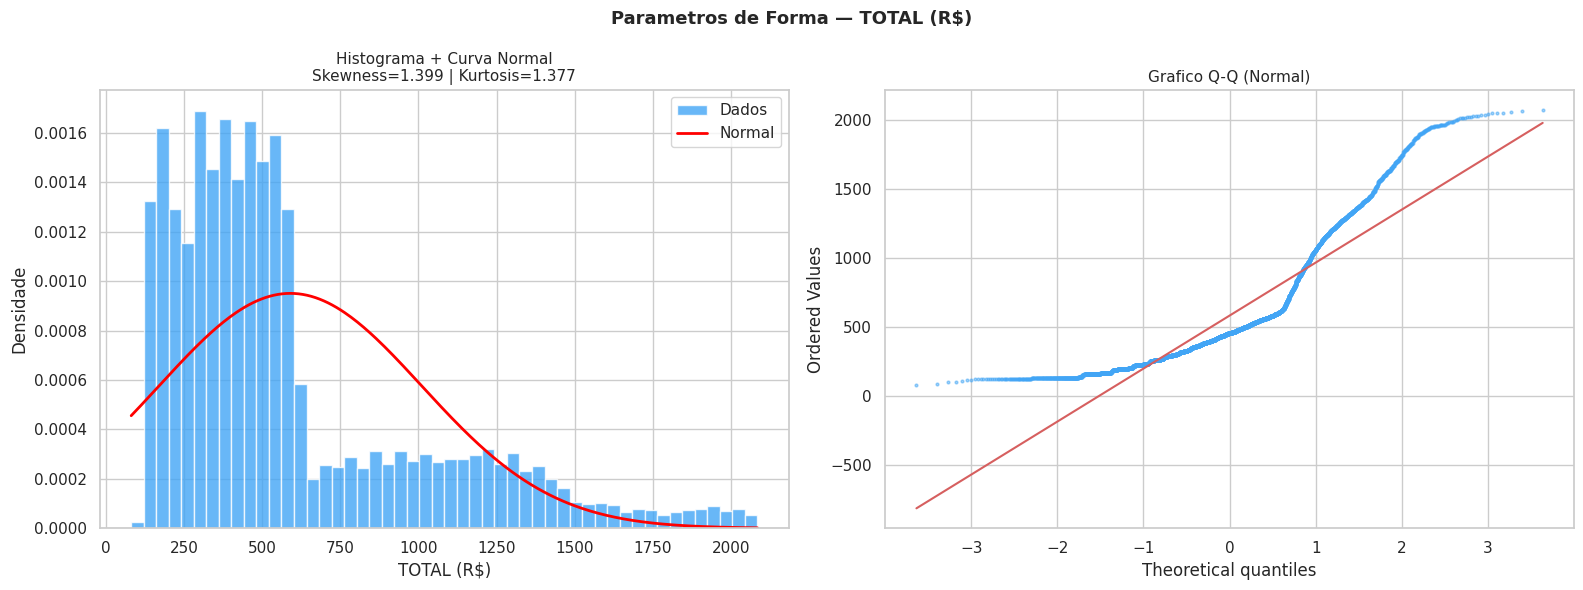

In [29]:
Atividade3_2_3()

### RELATÓRIO DA ATIVIDADE 3.1 e 3.2: OUTPUT

**CONCLUSÕES SOBRE AS ATIVIDADES:**

* **3.1.A1 — Gráficos de Pareto**: Os gráficos revelam que a maioria dos clientes possui plano ESSENTIAL, seguido por VIP e PRIME. O SUDESTE concentra o maior volume de clientes. O sexo MASCULINO é ligeiramente predominante. O estado civil CASADO é o mais frequente, seguido por SOLTEIRO.
* **3.1.A2 — Tabulação Cruzada**: A análise cruzada das variáveis qualitativas com `TIPO DA CONTA` mostra distribuição relativamente uniforme entre categorias por região e sexo, sugerindo que essas variáveis isoladas não determinam o tipo de plano contratado. O estado civil apresenta leve variação por categoria.
* **3.2.A1 — Estatística Descritiva (X)**: As variáveis `RENDA BRUTO (R$)` e `MEAN: proline` destacam-se pela maior amplitude de valores. `DEPENDENTES` é a única variável discreta. As variáveis `MEAN:` possuem coeficientes de variação distintos, indicando diferentes níveis de dispersão nos perfis de consumo de vinho.
* **3.2.A2 — Estatística Descritiva (y)**: O `TOTAL (R$)` apresenta distribuição assimétrica positiva, com média superior à mediana. Clientes PRIME gastam significativamente mais que VIP e ESSENTIAL. A variabilidade dentro de cada categoria (desvio padrão) é maior para PRIME, indicando maior heterogeneidade nesse segmento.
* **3.2.A3 — Parâmetros de Forma (y)**: A assimetria positiva e a curtose elevada confirmam que o TARGET não segue distribuição normal. O gráfico Q-Q evidencia os desvios em relação à normalidade, especialmente nas caudas. Isso justifica o uso de testes não-paramétricos nas análises seguintes (Etapa 3.3).


## **ETAPA 3.4**: Análise e Redução de Dimensionalidade

### Atividade (A1) - : Análise das Características (FEATURES):

*   **Removing features with low variance ($\sigma^2$)**

ANALISE DE FEATURES — METRICAS E CORRELACAO COM TARGET


,media,desvio_padrao,cv (%),corr_pearson,corr_spearman
feature,,,,,
RENDA BRUTO (R$),6048.7065,4979.1939,82.32,0.7739,0.6608
NOTA DE SATISFAÇÃO (%),68.8011,0.8733,1.27,0.2801,0.2535
MEAN: total_phenols,2.3062,0.6099,26.45,0.0177,0.0128
MEAN: hue,0.9570,0.2229,23.29,-0.0167,-0.0119
MEAN: nonflavanoid_phenols,0.3615,0.1241,34.34,-0.0160,-0.0121
MEAN: od280/od315_of_diluted_wines,2.6095,0.7045,27.00,-0.0147,-0.0079
MEAN: alcohol,12.9911,0.8066,6.21,-0.0144,-0.0141
MEAN: alcalinity_of_ash,19.5496,3.3526,17.15,0.0140,0.0059
MEAN: magnesium,99.8436,14.5101,14.53,0.0106,0.0150


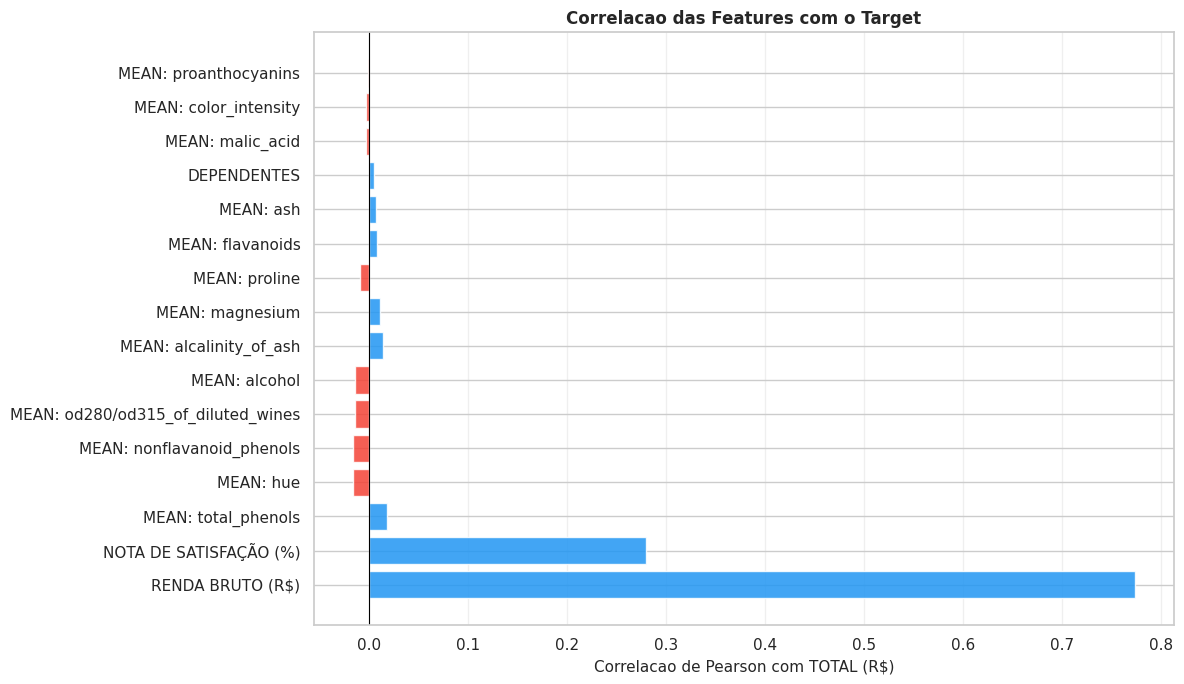

,media,desvio_padrao,cv (%),corr_pearson,corr_spearman
feature,,,,,
RENDA BRUTO (R$),6048.7065,4979.1939,82.32,0.7739,0.6608
NOTA DE SATISFAÇÃO (%),68.8011,0.8733,1.27,0.2801,0.2535
MEAN: total_phenols,2.3062,0.6099,26.45,0.0177,0.0128
MEAN: hue,0.9570,0.2229,23.29,-0.0167,-0.0119
MEAN: nonflavanoid_phenols,0.3615,0.1241,34.34,-0.0160,-0.0121
MEAN: od280/od315_of_diluted_wines,2.6095,0.7045,27.00,-0.0147,-0.0079
MEAN: alcohol,12.9911,0.8066,6.21,-0.0144,-0.0141
MEAN: alcalinity_of_ash,19.5496,3.3526,17.15,0.0140,0.0059
MEAN: magnesium,99.8436,14.5101,14.53,0.0106,0.0150


In [30]:
Atividade3_4_1()

### Atividade (A2): Análise das Correlações:

*   **Pearson Correlation Coefficient (PCC)**:
  *  Heatmap +
  *  Pairplot aplicado as Variáveis Quantitativas Contínuas.

*   **Plotar a Distribuição Normal**: Ajuste do melhor BINS.

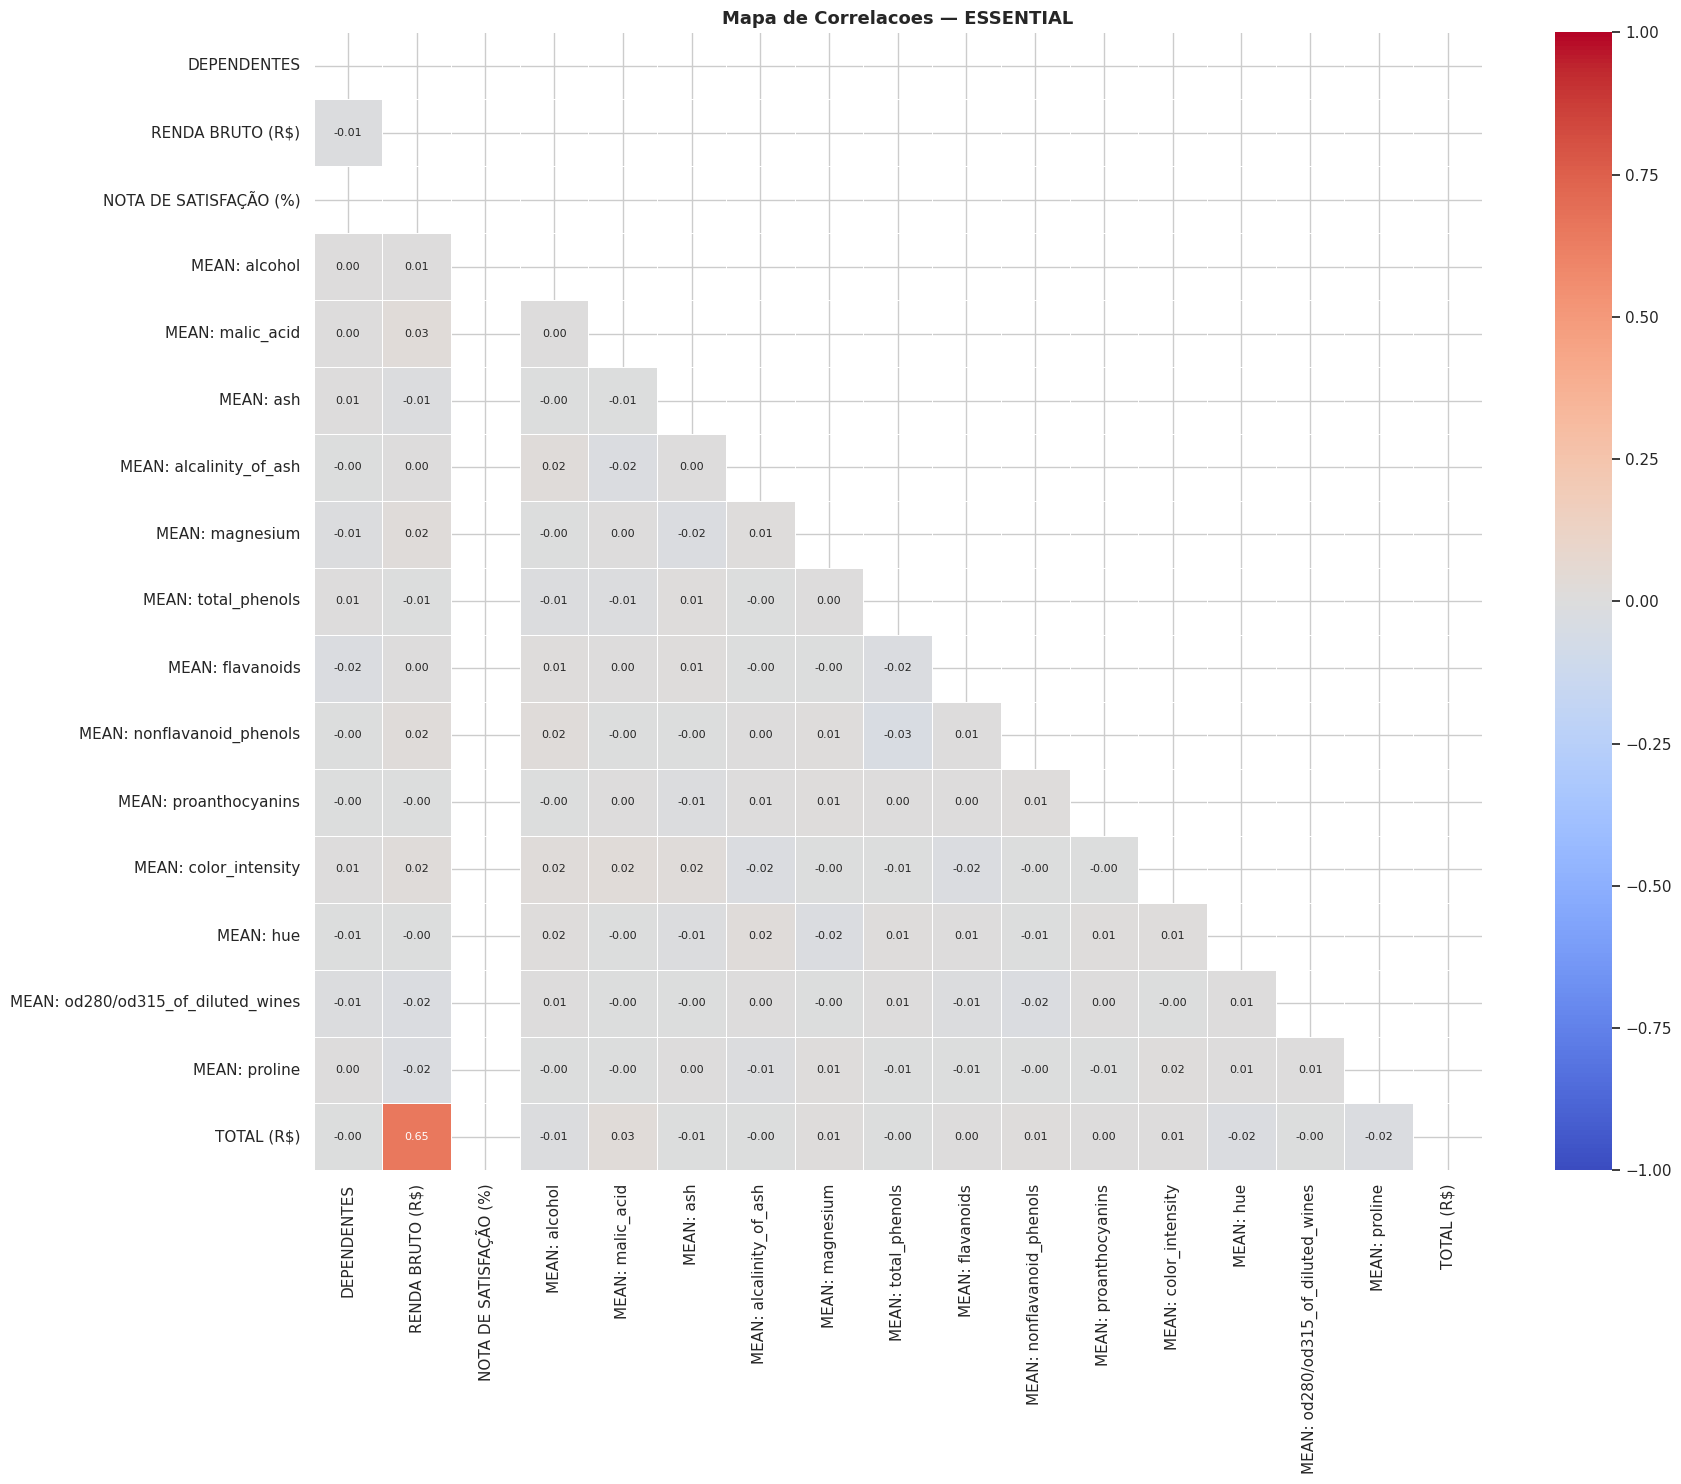

In [31]:
Atividade3_4_2('ESSENTIAL')

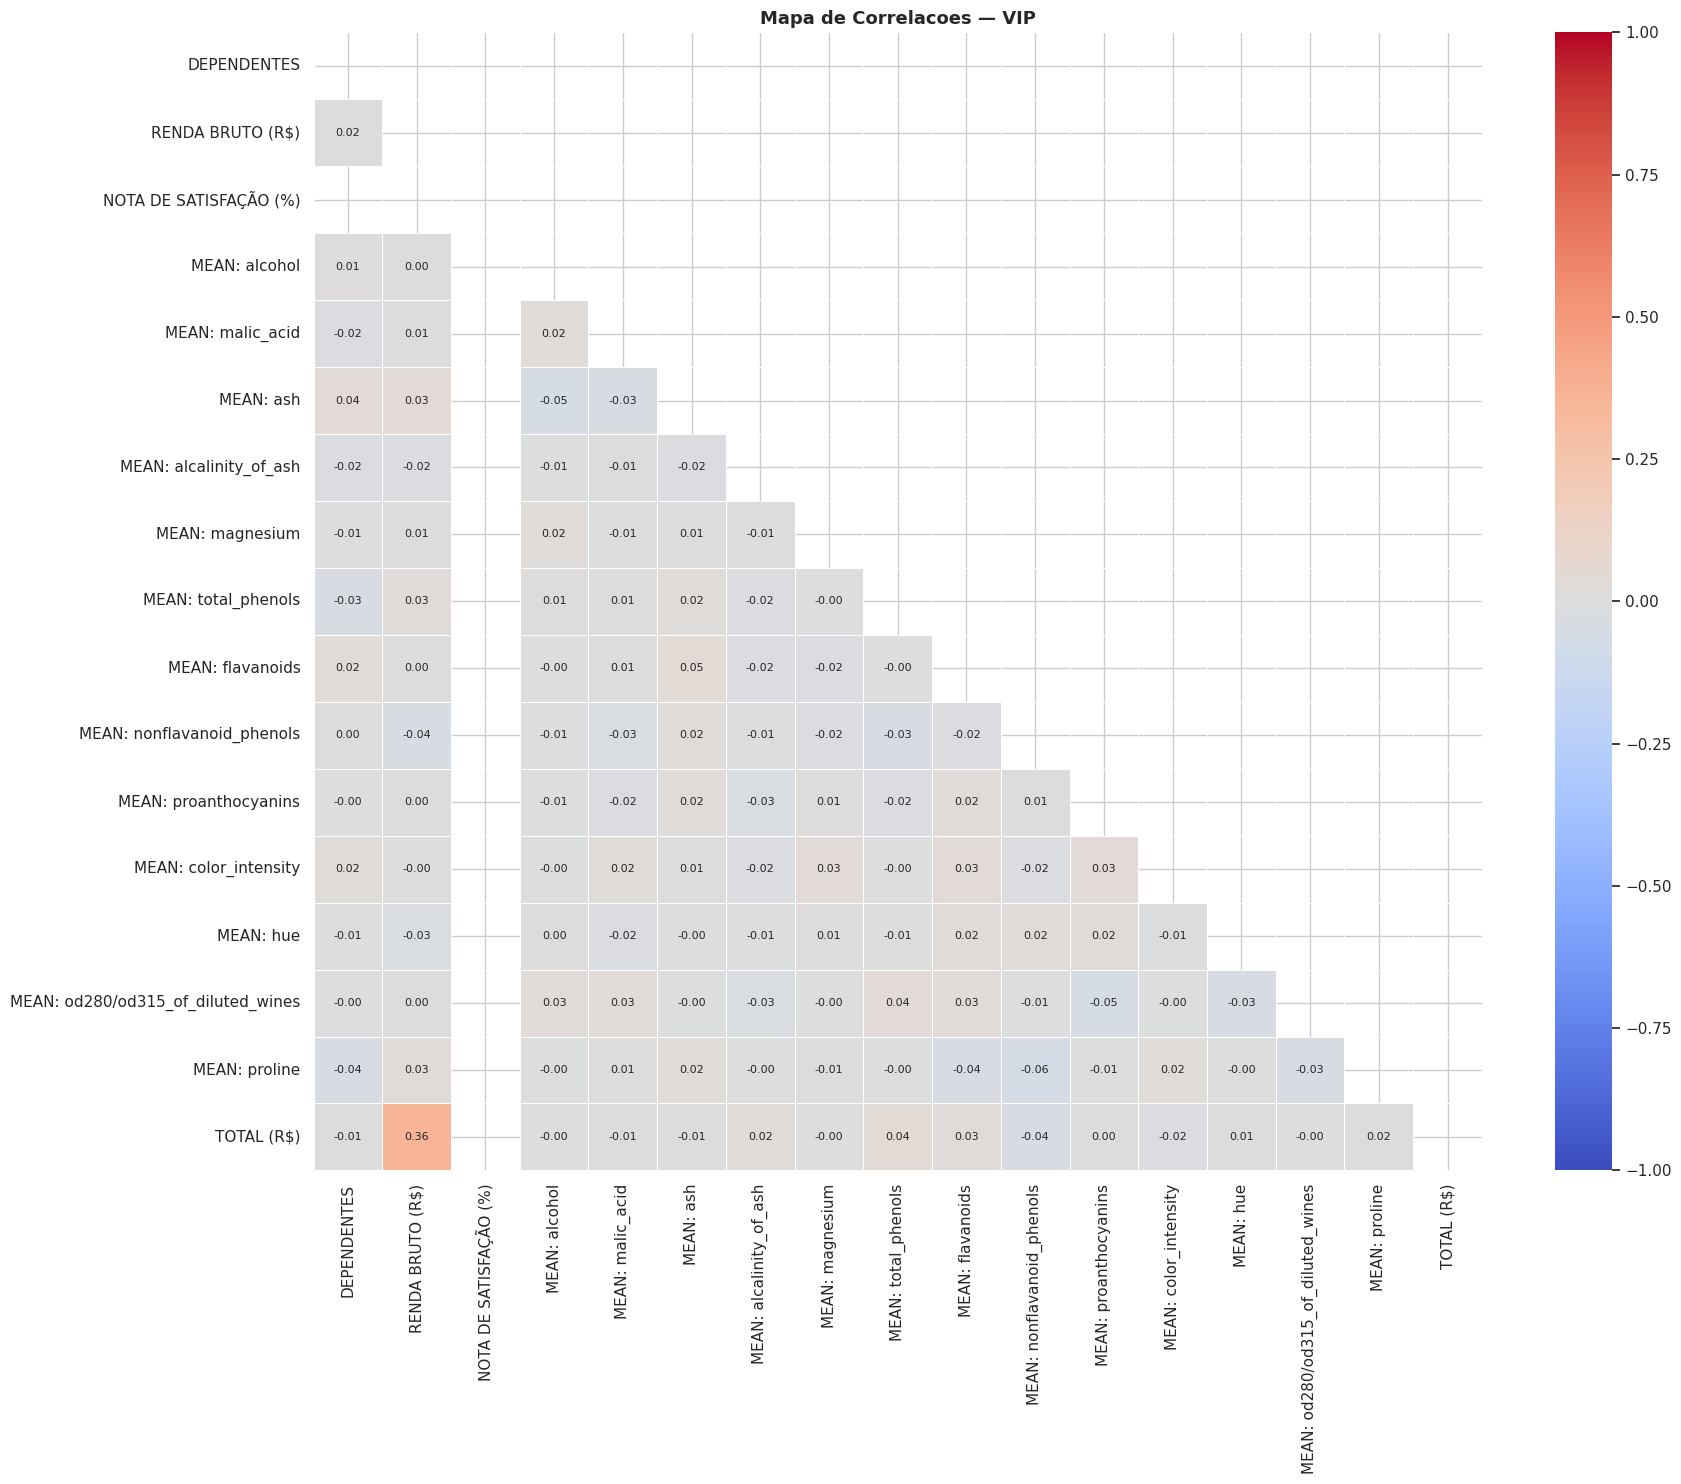

In [32]:
Atividade3_4_2('VIP')

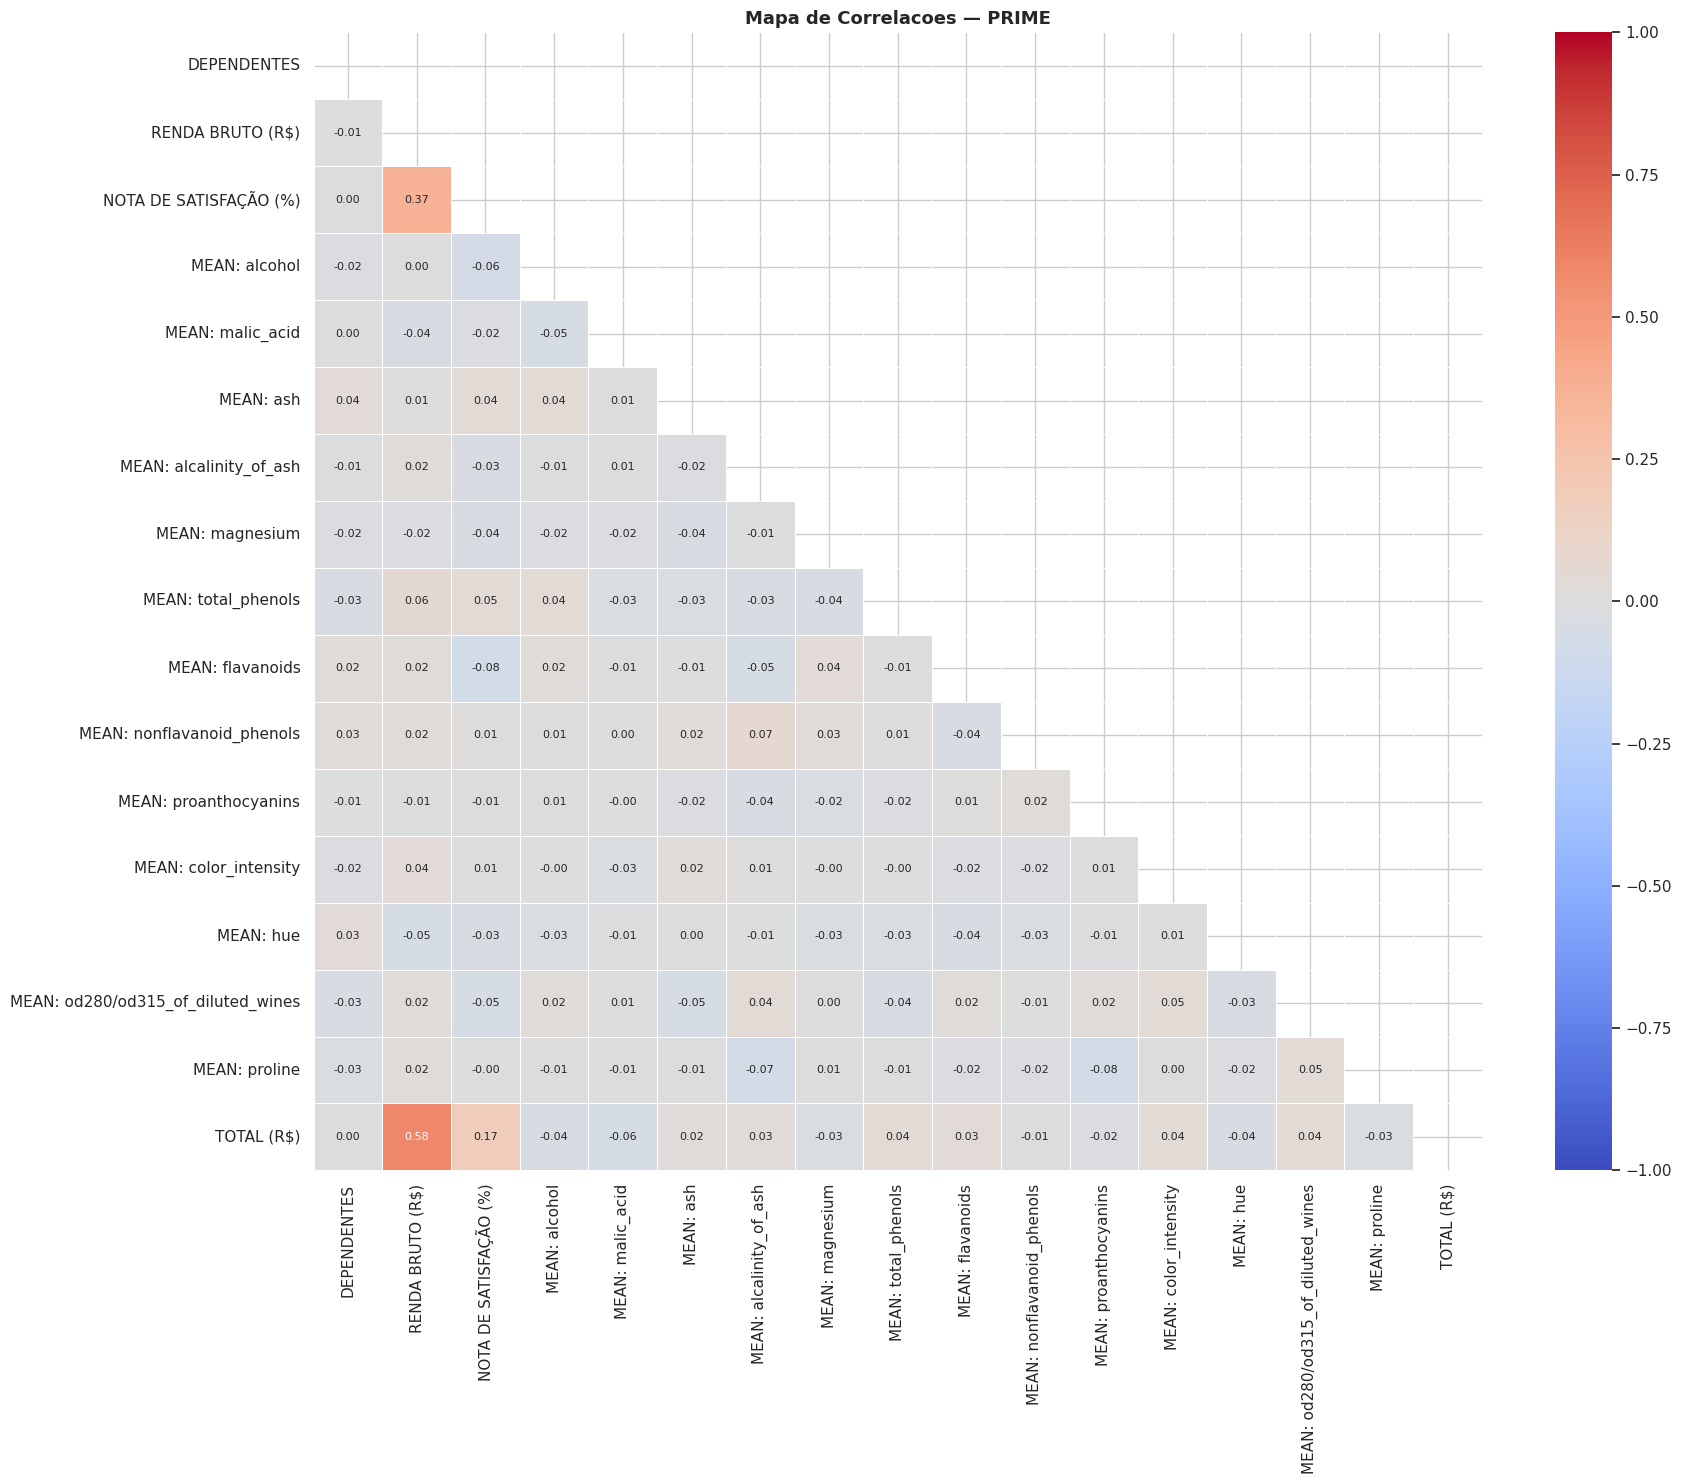

In [33]:
Atividade3_4_2('PRIME')

**SAÍDA ESPERADA DA PARTE 1 DO PROJETO**: Análise completa dos três (3) Datasets:

* Dataset: train
* Dataset: validation
* Dataset: test

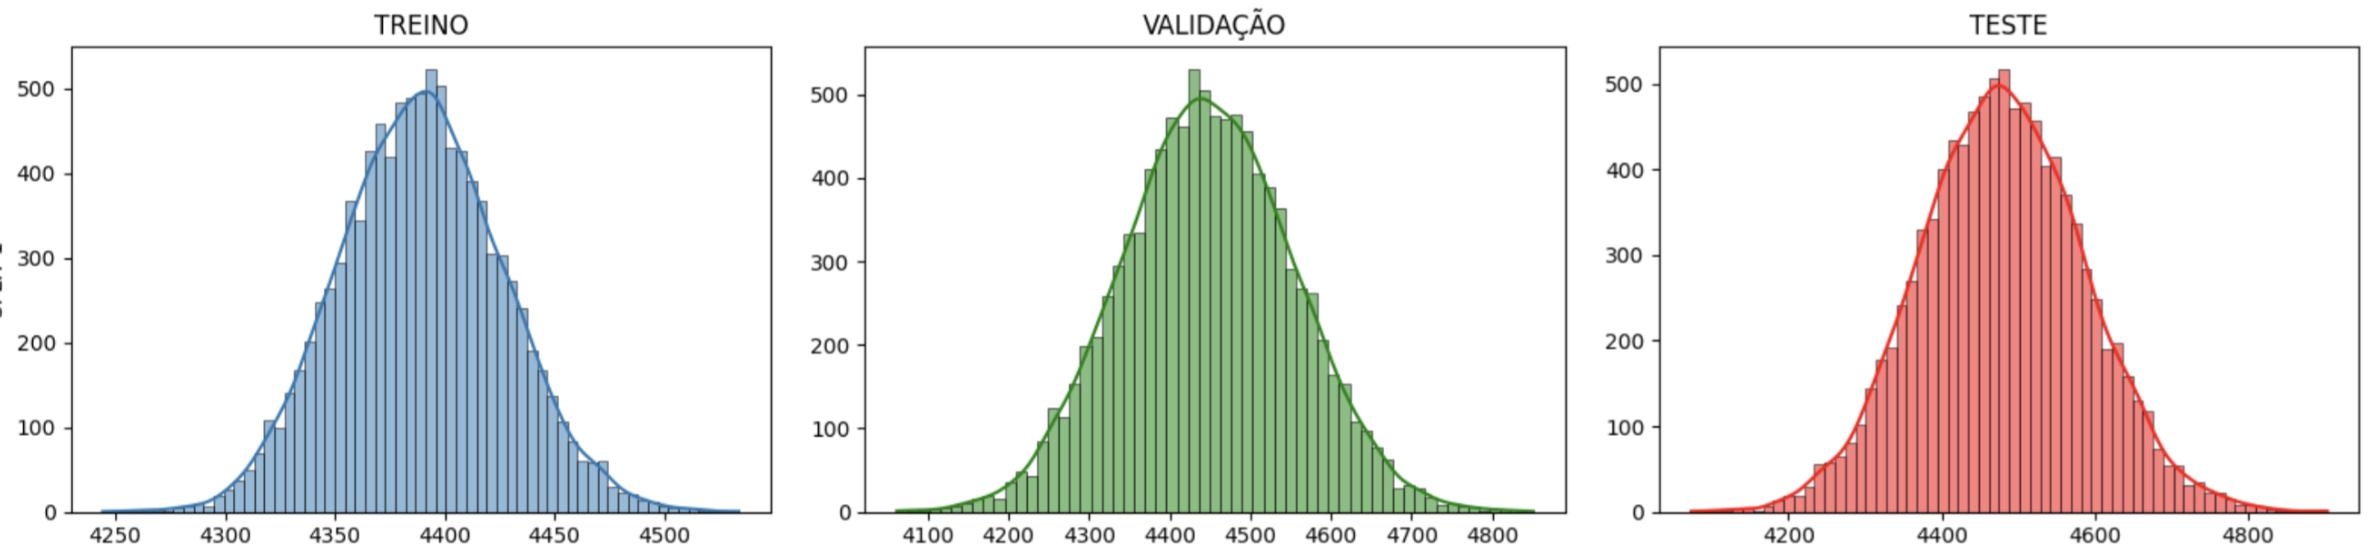

#OBRIGATÓRIO: CONVERTER IPYNB para PDF:

**PASSO A PASSO:**

1.   Fazer o download do seu IPYNB.
2.   Fazer o upload do seu IPYNB para área temporária: content.
3.   Rodar o código abaixo como **output.ipynb**: Gerar um HTML.
4.   Fazer o download do seu HTML e abrir em um Browser qualquer.
3.   Imprimir a página HTML em PDF. Pronto (UFA)::: 😅!

**MOTIVO:** Seus Gráficos, Códigos Python e Células **NÃO** sairão **" CORTADOS "** de uma página para outra.

In [34]:
# Conversao para HTML/PDF — compativel apenas com Google Colab
# %%shell
# jupyter nbconvert --to html /content/output.ipynb